# Introduction

This notebook contains an analysis of water samples for various viruses. The focus is on the taxonomy and Baltimore classification of these viruses. This data is compared with weather data. The weather data consists of the average values from the five days preceding the day the sample was collected at each location.

# Imports

In [1]:
# For data import
from pathlib import Path # for handling file paths
import re # for regular expressions to create valid dataframe names

# For data merging
import os # for file and directory operations

import pandas as pd # for data manipulation
import numpy as np # for numerical operations
import seaborn as sns # for data visualization
import matplotlib.pyplot as plt # for plotting
import plotly.express as px # for interactive plots
import plotly.graph_objects as go # for customized interactive plots
from skbio.diversity.alpha import shannon # for calculating alpha diversity
from skbio.diversity import beta_diversity # for calculating beta diversity
from skbio.stats.ordination import pcoa # for principal coordinates analysis
from scipy.stats import pearsonr # for correlation analysis

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Data Import

## Load Samplings with viruses information

In [2]:
def find_folder(*path_parts):
    possible_folders = [
        Path(*path_parts),
        Path("..") / Path(*path_parts),
    ]

    for folder in possible_folders:
        if folder.exists():
            return folder

    raise FileNotFoundError(f"Folder not found: {'/'.join(path_parts)}")


def load_merged_reads_dataframes(folder_path):
    created_dataframes = {}

    for csv_file in sorted(Path(folder_path).glob("*.csv")):
        dataframe_name = csv_file.stem
        df = pd.read_csv(csv_file)

        created_dataframes[dataframe_name] = df

    return created_dataframes


samplings_dir = find_folder("data", "samplings_with_virus_information")
merged_reads_dataframes = load_merged_reads_dataframes(samplings_dir)

# Control
print("Merged reads DataFrames:", merged_reads_dataframes)

Merged reads DataFrames: {'df_copenhagen_merged_reads_with_virus_information':                 name    taxid  ERR14789322  ERR14789323  ERR14789324  \
0     Mastadenovirus    10509          NaN          NaN          NaN   
1     Mastadenovirus    10509          NaN          NaN          NaN   
2     Mastadenovirus    10509          NaN          NaN          NaN   
3     Mastadenovirus    10509          NaN          NaN          NaN   
4     Mastadenovirus    10509          NaN          NaN          NaN   
...              ...      ...          ...          ...          ...   
1693    Baldwinvirus  3153089          NaN          NaN          NaN   
1694      Hodnevirus  3153200          NaN          NaN          NaN   
1695      Risoevirus  3424972          NaN          NaN          NaN   
1696   Margaeryvirus  3425048          NaN          NaN          NaN   
1697    Nicoomyvirus  3425078          NaN         0.18          NaN   

      ERR14789325  ERR14789326  ERR14789327  ERR14789328

# General Analysis of Measured Viruses

# Completeness of Virus Data

In [3]:
# Check how many lines contain virus information
for dataframe_name, df in merged_reads_dataframes.items():
    has_virus_info = df["taxid"].notna()

    print(
        f"{dataframe_name}: "
        f"{has_virus_info.sum()} Zeilen mit Virusinformationen, "
        f"{(~has_virus_info).sum()} Zeilen ohne Virusinformationen"
    )

df_copenhagen_merged_reads_with_virus_information: 1698 Zeilen mit Virusinformationen, 0 Zeilen ohne Virusinformationen
df_global_merge_with_virus_information: 4366 Zeilen mit Virusinformationen, 0 Zeilen ohne Virusinformationen
df_guangzhou_merged_reads_with_virus_information: 1376 Zeilen mit Virusinformationen, 0 Zeilen ohne Virusinformationen
df_kualalumpur_merged_reads_with_virus_information: 1236 Zeilen mit Virusinformationen, 0 Zeilen ohne Virusinformationen
df_melbourne_merged_reads_with_virus_information: 2880 Zeilen mit Virusinformationen, 0 Zeilen ohne Virusinformationen
df_quito_merged_reads_with_virus_information: 1178 Zeilen mit Virusinformationen, 0 Zeilen ohne Virusinformationen
df_regina_merged_reads_with_virus_information: 1967 Zeilen mit Virusinformationen, 0 Zeilen ohne Virusinformationen
df_seattle_merged_reads_with_virus_information: 1594 Zeilen mit Virusinformationen, 0 Zeilen ohne Virusinformationen
df_yaounde_merged_reads_with_virus_information: 2585 Zeilen mit 

# Compilation of the Dictionary for the Cities

In [4]:
# Define find_folder here as well, so this cell also works after a kernel restart
def find_folder(*path_parts):
    possible_folders = [
        Path(*path_parts),
        Path("..") / Path(*path_parts),
    ]

    for folder in possible_folders:
        if folder.exists():
            return folder

    raise FileNotFoundError(f"Folder not found: {'/'.join(path_parts)}")


# Locate both data directories independently of the notebook's working directory
samplings_dir = Path(find_folder("data", "samplings_with_virus_information"))
weather_dir = Path(find_folder("data", "samplings"))

# Define the filename suffix for each data type
samplings_suffix = "_merged_reads_with_virus_information.csv"
weather_suffix = "_weather.csv"

# Map normalized city names to their sampling filenames
samplings_files = {
    file.name.removeprefix("df_")
             .removesuffix(samplings_suffix)
             .replace("_", "")
             .lower(): file.name
    for file in sorted(samplings_dir.glob(f"*{samplings_suffix}"))
}

# Map normalized city names to their weather filenames
weather_files = {
    file.name.removesuffix(weather_suffix)
             .replace("_", "")
             .lower(): file.name
    for file in sorted(weather_dir.glob(f"*{weather_suffix}"))
}

# Select cities for which both sampling and weather files exist
common_cities = samplings_files.keys() & weather_files.keys()

# Store the matching sampling and weather filenames as tuples
cities = {
    city: (samplings_files[city], weather_files[city])
    for city in sorted(common_cities)
}

# Report missing matches clearly instead of returning an empty dictionary
if not cities:
    raise ValueError(
        f"No matching file pairs found. "
        f"Sampling directory: {samplings_dir.resolve()}, "
        f"weather directory: {weather_dir.resolve()}"
    )

print(cities)

{'copenhagen': ('df_copenhagen_merged_reads_with_virus_information.csv', 'Copenhagen_weather.csv'), 'guangzhou': ('df_guangzhou_merged_reads_with_virus_information.csv', 'Guangzhou_weather.csv'), 'kualalumpur': ('df_kualalumpur_merged_reads_with_virus_information.csv', 'KualaLumpur_weather.csv'), 'melbourne': ('df_melbourne_merged_reads_with_virus_information.csv', 'Melbourne_weather.csv'), 'quito': ('df_quito_merged_reads_with_virus_information.csv', 'Quito_weather.csv'), 'regina': ('df_regina_merged_reads_with_virus_information.csv', 'Regina_weather.csv'), 'seattle': ('df_seattle_merged_reads_with_virus_information.csv', 'Seattle_weather.csv'), 'yaounde': ('df_yaounde_merged_reads_with_virus_information.csv', 'Yaounde_weather.csv')}


In [5]:
# --- Mapping of the original CSV columns to shorter names in a dictionary ---
weather_features = {
    'temperature_2m_mean (°C)':      'Temperatur',
    'rain_sum (mm)':                 'Regen',
    'relative_humidity_2m_mean (%)': 'Luftfeuchtigkeit',
}

# TODO: Nachprüfen, ob die ENA-Beschreibung korrekt ist
# --- Loading the ENA metadata ---
# It links each sample ID to its sampling date
# The ena_data.tsv file contains information about the samples analyzed
print("Lade ENA-Metadaten...")
# Search for the ENA metadata file directly instead of only searching for its folder.
# This is necessary because `data/climate_analysis` exists, but `ena_data.tsv`
# can also be stored in `climate_analysis/ena_data.tsv`.
ena_data_candidates = [
    Path("climate_analysis") / "ena_data.tsv",
    Path("data") / "climate_analysis" / "ena_data.tsv",
    Path("..") / "climate_analysis" / "ena_data.tsv",
    Path("..") / "data" / "climate_analysis" / "ena_data.tsv",
]

ena_data_path = next(
    (candidate for candidate in ena_data_candidates if candidate.exists()),
    None
)

if ena_data_path is None:
    raise FileNotFoundError(
        "Could not find `ena_data.tsv`. Checked: "
        + ", ".join(str(path) for path in ena_data_candidates)
    )

ena_data = pd.read_csv(ena_data_path, sep='\t')
print(f"ENA-Daten: {len(ena_data)} Samples\n")

# TODO: Nachprüfen, ob die PCoA-Beschreibung korrekt ist
# --- Creation of the Results Dictionaries ---
# For each city, the following data is stored separately:
#   - the adjusted analysis data,
#   - the virus abundance matrix,
#   - the PCoA results are stored separately
total_data = {}
total_samplings  = {}
total_pcoa   = {} # It's the result of a Principal Coordinates Analysis (German: Hauptkoordinatenanalyse)


# --- Processing all cities and their previously assigned file pairs ---
for city, (sampling_file, weather_file) in cities.items():
    # Load the virus table from the sampling directory
    sampling_path = samplings_dir / sampling_file
    sampling_df = pd.read_csv(sampling_path, index_col=0)

    # Keep only sequencing-run columns
    # All other columns contain taxonomy metadata
    sample_columns = sampling_df.columns[
        sampling_df.columns.isin(ena_data['run_accession'])
    ]
    if sample_columns.empty:
        raise ValueError(f'No ENA sample columns found in {sampling_path}')
    sampling_df = sampling_df.loc[:, sample_columns]
    
    # interpretation of missing abundances as 0:
    # Abundance describes how frequently or in what quantity a virus occurs in a sample)
    sampling_df = sampling_df.fillna(0)
    
    # Transpose the DataFrame
    #   - Rows = samples,
    #   - Columns = viruses
    sampling_df = sampling_df.T

    # Calculating alpha diversity:
    # Alpha diversity describes the biological diversity within a single sample
    # The Shannon index describes the diversity within a single sample based on virus abundances
    alpha_div = pd.DataFrame([
        {
            'Sample': sid,
            'Shannon': shannon(sampling_df.loc[sid].values)
        }
        
        for sid in sampling_df.index
    ])

    # TODO: Nachprüfen, ob die run_accession-Beschreibung korrekt ist
    # Filtering ENA entries
    # Select only ENA entries whose `run_accession` appears in the virus data
    # The Run Accession is a unique identifier for a single sequencing run in the European Nucleotide Archive (ENA)
    #
    # Then, only the sample ID and sampling date are retained and renamed
    ena_city = (
        ena_data[ena_data['run_accession'].isin(alpha_div['Sample'])]
        [['run_accession', 'collection_date']]
        .copy()
        .rename(columns={'run_accession': 'Sample', 'collection_date': 'Date'})
    )
    
    # Converting dates to actual pandas date values
    ena_city['Date'] = pd.to_datetime(ena_city['Date'])
    
    # TODO: Nachprüfen, ob die Shannon-Beschreibung korrekt ist
    # Link Shannon values and sampling data using the shared sample ID
    # 
    # Shannon values are measures of diversity within a sample—in
    # (in our case the Shannon values are measures of the diversity of viruses in a sample)
    # 
    # They take into account:
    #   - How many different viruses are present
    #   - How evenly their abundances are distributed
    # 
    # Shannon = 0: Only one virus is present.
    # Low value: Few viruses, or one virus is strongly dominant.
    # High value: Many viruses are present in relatively equal numbers.
    # 
    # There is no general threshold for “high” or “low.”
    # Shannon values should primarily be compared between comparable samples within the same dataset.
    data = alpha_div.merge(ena_city, on='Sample')

    # Loading weather data for the city
    weather_path = weather_dir / weather_file
    weather_df = pd.read_csv(weather_path)
    
    # Converting the time column in the weather data
    weather_df['time'] = pd.to_datetime(weather_df['time'])

    # Create a new, initially empty result column for each weather characteristic
    for csv_column, col_name in weather_features.items():
        data[col_name] = np.nan
        
        # For each sample, determine the time period from the sampling date back to four days prior
        for i, row in data.iterrows():
            # Select only weather data within this five-day window (inclusive)
            start = row['Date'] - pd.Timedelta(days=4)
            mask = (weather_df['time'] >= start) & (weather_df['time'] <= row['Date'])
            
            # Calculate the mean value of the weather variable and store it in the "Sample" row
            data.at[i, col_name] = weather_df.loc[mask, csv_column].mean()

    # Remove samples that are missing a weather value or the Shannon index
    data_clean = data.dropna(subset=list(weather_features.values()) + ['Shannon'])
    
    # TODO: Nachprüfen, ob die Bray-Curtis-Distanz-Beschreibung korrekt ist
    # Calculation of beta diversity between all sample pairs as the Bray-Curtis distance
    # The Bray-Curtis distance describes how different the composition of two samples is.
    # (In our case, it compares the virus abundances of two samples.)
    # 
    # The values typically range from 0 to 1:
    #   0: Both samples have the same viral composition and the same abundances.
    #   close to 0: The samples are very similar.
    #   close to 1: The samples are very different.
    #   1: They have no viruses in common with positive abundance.
    bray_curtis_distances = beta_diversity('braycurtis', sampling_df.values, sampling_df.index)
    
    # Reducing the distance matrix to the first two visualizable PCoA dimensions
    # `dimensions=2` avoids calculating unnecessary dimensions and removes the runtime warning
    # about computing all dimensions.
    #
    # Bray-Curtis distances can produce negative eigenvalues because they are not always
    # perfectly Euclidean. For this exploratory 2D ordination, we disable that warning.
    pcoa_res = pcoa(
        bray_curtis_distances,
        dimensions=2,
        warn_neg_eigval=False
    )

    # Save all results under the city name so they can be retrieved later
    total_data[city] = data_clean
    total_samplings[city] = sampling_df
    total_pcoa[city]  = pcoa_res

# Merge the cleaned data from all cities into a single DataFrame
# `ignore_index=True` creates a new, continuous row index for this purpose
total_samples_df = pd.concat(total_data.values(), ignore_index=True)

# Determine global display limits from all cities so that subsequent charts
# use the same axis and color scales and are directly comparable
global_display_limits = {
    'Temperatur':       (total_samples_df['Temperatur'].min() - 2,       total_samples_df['Temperatur'].max() + 2),
    'Regen':            (total_samples_df['Regen'].min() - 2,            total_samples_df['Regen'].max() + 2),
    'Luftfeuchtigkeit': (total_samples_df['Luftfeuchtigkeit'].min() - 2, total_samples_df['Luftfeuchtigkeit'].max() + 2),
    'Shannon':          (total_samples_df['Shannon'].min() - 0.2,        total_samples_df['Shannon'].max() + 0.2),
}

Lade ENA-Metadaten...
ENA-Daten: 678 Samples



# Analysis

## Exploratory Analysis of Weather Data

### Time Series Plots
The following plot shows how the environmental parameters have changed over time.
The plot is interactive, with zoom and hover functions.

In [6]:
def plot_weather_features_for_all_cities(cities, weather_dir):
    """
    Create separate Plotly line plots for each weather feature and each city.

    For every city in the `cities` dictionary, this function loads the matching
    weather CSV file and creates one individual line plot for each selected
    weather variable:
        - mean temperature
        - mean relative humidity
        - rain sum

    The plots are displayed directly in the notebook and are also stored in
    a nested dictionary so they can be reused later.
    """

    # Define which weather columns should be plotted.
    # The keys are the exact column names in the weather CSV files.
    # The values are readable names used in plot titles and axis labels.
    weather_features = {
        "temperature_2m_mean (°C)": "Temperature mean (°C)",
        "relative_humidity_2m_mean (%)": "Relative humidity mean (%)",
        "rain_sum (mm)": "Rain sum (mm)",
    }

    # This dictionary will store all generated Plotly figures.
    #
    # Structure:
    # weather_figures[city][feature_name] = Plotly figure
    #
    # Example:
    # weather_figures["copenhagen"]["Temperature mean (°C)"]
    weather_figures = {}

    # Loop over all cities in the cities dictionary.
    #
    # Each entry in cities has the structure:
    # city: (sampling_file, weather_file)
    #
    # In this function, only the weather file is needed.
    # The underscore `_` is used for the sampling file to show that it is ignored.
    for city, (_, weather_file) in cities.items():

        # Build the full path to the weather CSV file of the current city.
        weather_path = Path(weather_dir) / weather_file

        # Load the city's weather data into a pandas DataFrame.
        df_weather = pd.read_csv(weather_path)

        # Convert the time column to datetime format.
        # This allows Plotly to correctly display the x-axis as a time axis.
        df_weather["time"] = pd.to_datetime(df_weather["time"])

        # Create a nested dictionary for the current city.
        # Each weather feature plot will be stored inside this dictionary.
        weather_figures[city] = {}

        # Loop over all selected weather features.
        #
        # `column` is the original column name in the CSV file.
        # `feature_name` is the readable name used in the plot.
        for column, feature_name in weather_features.items():

            # Create a Plotly line plot for the current weather feature.
            fig = px.line(
                df_weather,
                x="time",
                y=column,
                title=f"{feature_name} - {city.title()}",
                labels={
                    "time": "Date",
                    column: feature_name,
                },
            )

            # Set the plot height so that many plots can still be viewed comfortably.
            fig.update_layout(height=300)

            # Store the figure in the nested dictionary.
            # This allows later access without recreating the plot.
            weather_figures[city][feature_name] = fig

            # Display the figure directly in the notebook.
            # Because this happens inside the loop, all plots are shown one after another.
            fig.show()

    # Return the dictionary containing all generated figures.
    return weather_figures


# Run the function and store all created Plotly figures.
weather_figures = plot_weather_features_for_all_cities(cities, weather_dir)

#### Standardized Plotly Line Plot per City

In [7]:
def plot_weather_for_all_cities(cities, weather_dir):
    """
    Create one standardized Plotly line plot per city.

    Each city has its own weather CSV file. The function loads each file,
    standardizes the selected weather variables, creates one interactive
    line plot per city, displays the plots below each other, and returns
    all Plotly figures in a dictionary.
    """

    # Map the original column names from the weather CSV files to shorter,
    # more readable names that will be used in the plot legend.
    weather_columns = {
        'temperature_2m_mean (°C)': 'Temperature mean',
        'relative_humidity_2m_mean (%)': 'Relative humidity mean',
        'rain_sum (mm)': 'Rain sum',
    }

    # Store all generated Plotly figures here.
    # The city name is used as the dictionary key.
    figures = {}

    # Loop through all cities in the cities dictionary.
    # Each dictionary entry contains two filenames:
    #   1. the sampling/virus file
    #   2. the corresponding weather file
    # The underscore `_` means that the sampling file is intentionally ignored here,
    # because this function only needs the weather file.
    for city, (_, weather_file) in cities.items():
        # Build the full path to the city's weather CSV file.
        weather_path = Path(weather_dir) / weather_file

        # Load the weather data for the current city into a DataFrame.
        df_weather = pd.read_csv(weather_path)

        # Convert the time column from text to real datetime values.
        # This ensures that Plotly treats the x-axis as a time axis.
        df_weather['time'] = pd.to_datetime(df_weather['time'])

        # Transform weather values to a unitless, comparable scale.
        # z-score = (value - mean) / standard deviation
        # This makes temperature, humidity, and rain comparable in one plot.
        #
        # Interpretation of standardized values:
        #   0  = average value for this variable in this city
        #   >0 = above average
        #   <0 = below average
        #   1  = one standard deviation above average
        #  -1  = one standard deviation below average
        standardized_columns = []

        # Standardize each selected weather variable separately.
        # This is important because temperature, humidity, and rain have
        # different units and different value ranges.
        for original_column, readable_name in weather_columns.items():
            # Create the name for the new standardized column.
            standardized_column = f'{readable_name} (standardized)'

            # Calculate the mean and standard deviation for the current variable.
            mean_value = df_weather[original_column].mean()
            std_value = df_weather[original_column].std()

            # If the standard deviation is missing or zero, all values are identical
            # or cannot be standardized in a meaningful way.
            # In that case, the standardized values are set to 0.
            if pd.isna(std_value) or std_value == 0:
                df_weather[standardized_column] = 0
            else:
                # Apply z-score standardization:
                # subtract the mean and divide by the standard deviation.
                df_weather[standardized_column] = (
                    df_weather[original_column] - mean_value
                ) / std_value

            # Store the standardized column name so it can be passed to Plotly later.
            standardized_columns.append(standardized_column)

        # Create an interactive line plot for the current city.
        # Plotly draws one line for each standardized weather variable.
        fig = px.line(
            df_weather,
            x='time',
            y=standardized_columns,
            title=f'Standardized weather data - {city.title()}',

            # Rename axis labels and the legend label to make the plot easier to read.
            labels={
                'time': 'Date',
                'value': 'Standardized value',
                'variable': 'Weather feature',
            }
        )

        # Adjust the plot layout.
        # A fixed height keeps the plots compact when several cities are shown below each other.
        fig.update_layout(
            height=350,
            legend_title_text='Weather feature'
        )

        # Store the figure so it can be reused later, for example for exporting.
        figures[city] = fig

        # Display the figure immediately in the notebook.
        # Because this happens inside the loop, the plots appear below each other.
        fig.show()

    # Return all figures as a dictionary:
    #   key   = city name
    #   value = Plotly figure object
    return figures


# Run the function and store all created figures.
weather_figures = plot_weather_for_all_cities(cities, weather_dir)

#### Correlation Matrix

The correlation plots show the degree of correlation between weather variables within a city.

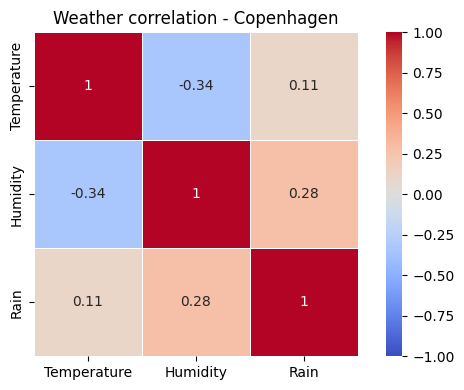

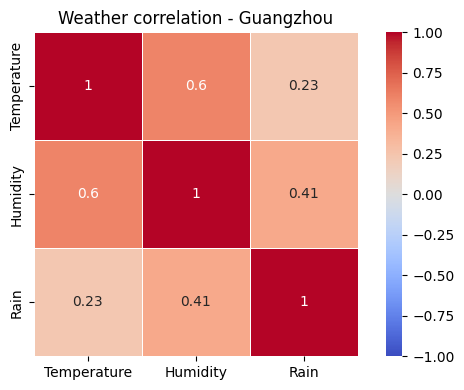

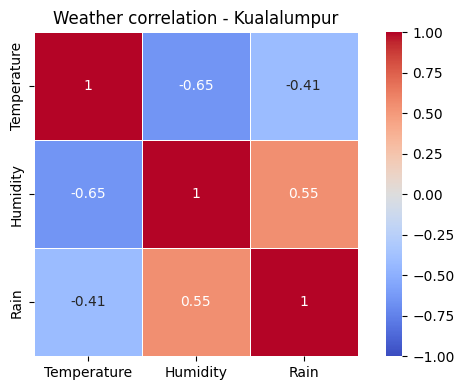

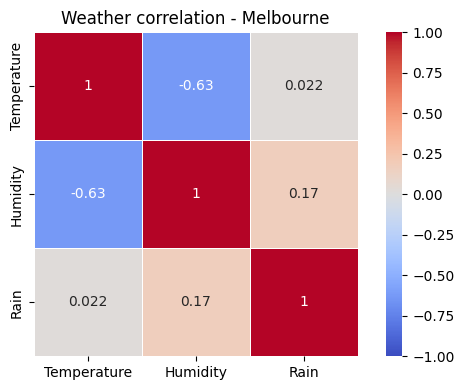

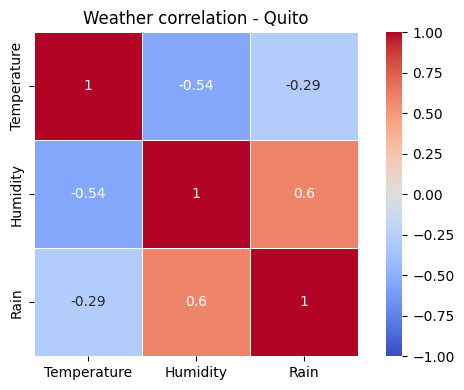

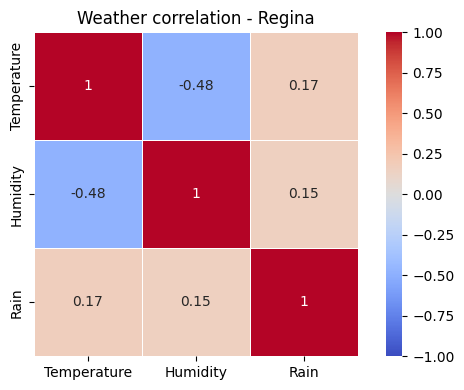

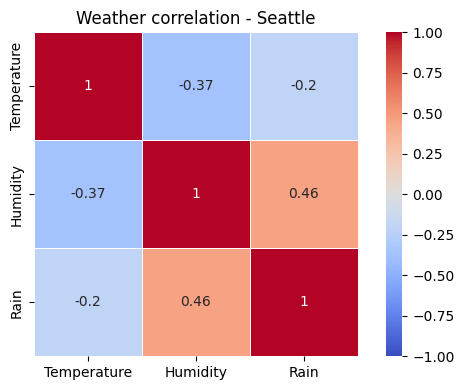

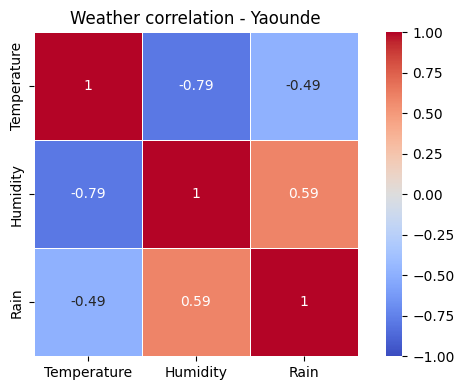

In [8]:
def plot_weather_correlation_for_all_cities(cities, weather_dir):
    """
    Create one correlation heatmap for the weather data of each city.

    For every city, the corresponding weather CSV file is loaded. Then the
    correlations between the selected weather variables are calculated and
    displayed as a heatmap.
    """

    # Select the weather variables that should be included in the correlation matrix.
    # The keys are the original column names in the CSV files.
    # The values are shorter names used as labels in the heatmap.
    weather_features = {
        "temperature_2m_mean (°C)": "Temperature",
        "relative_humidity_2m_mean (%)": "Humidity",
        "rain_sum (mm)": "Rain",
    }

    # Store the correlation matrices for later use or inspection.
    correlation_matrices = {}

    # Loop over all cities and their matching files.
    # The sampling file is not needed here, so it is ignored with `_`.
    for city, (_, weather_file) in cities.items():
        # Build the full file path to the city's weather CSV file.
        weather_path = Path(weather_dir) / weather_file

        # Load the weather data for the current city.
        df_weather = pd.read_csv(weather_path)

        # Keep only the selected weather columns and rename them for readability.
        df_correlation = df_weather[list(weather_features.keys())].rename(
            columns=weather_features
        )

        # Calculate the Pearson correlation matrix.
        # Values range from -1 to 1:
        #   1  = strong positive correlation
        #   0  = no linear correlation
        #  -1  = strong negative correlation
        correlation_matrix = df_correlation.corr()

        # Save the matrix so it can be reused later without recalculating it.
        correlation_matrices[city] = correlation_matrix

        # Create a new figure for the current city.
        plt.figure(figsize=(6, 4))

        # Draw the correlation matrix as a heatmap.
        sns.heatmap(
            correlation_matrix,
            annot=True,
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            center=0,
            square=True,
            linewidths=0.5
        )

        # Add a city-specific title and improve the layout.
        plt.title(f"Weather correlation - {city.title()}")
        plt.tight_layout()

        # Display the plot in the notebook.
        plt.show()

    return correlation_matrices


weather_correlation_matrices = plot_weather_correlation_for_all_cities(cities, weather_dir)

#### Findings

TODO: Auswertung in Bezug auf folgende Fragen:

Gibt es saisonale Muster?
Treten Extremereignisse auf?
Gibt es Messlücken?

<b>Scale</b><br>
The correlation values range from -1 to 1:
<br><br>

<b>1:</b> Strong positive correlation<br>
When variable A increases, variable B tends to increase as well.
<br><br>

<b>0:</b> No clear linear correlation
<br><br>

<b>-1:</b> Strong negative correlation<br>
When variable A increases, variable B tends to decrease.
<br><br>

<b>Variables</b><br>
The plots compare the following three weather variables:
<ul>
    <li>Temperature</li>
    <li>Humidity</li>
    <li>Rain</li>
</ul>

<b>Interpretation</b><br>

<b>Temperature vs. Humidity</b><br>
A negative correlation indicates that warmer days tend to have lower relative humidity.
<br><br>

<b>Temperature vs. Rain</b><br>
Shows whether warmer days are generally associated with more or less rainfall.
<br><br>

<b>Humidity vs. Rain</b><br>
A positive correlation is expected, as higher rainfall is often associated with increased humidity.
<br><br>

<b>Limitations of Interpretation</b><br>
Correlation does not imply causation. A strong correlation only indicates that two variables tend to change together; it does not mean that one variable causes the other.

## Analysis of Hosts in Data

### Virus Distribution by Hosts

In [9]:
from pathlib import Path
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Interactive host ranking table.
#
# This cell allows you to:
#   - search hosts by host tax ID
#   - search hosts by host name
#   - sort the table by virus count, host name, or host tax ID
#   - switch between ascending and descending order
#   - control how many rows are displayed
#
# The code expects either:
#   1. an existing DataFrame called `host_counts`
#      with the columns:
#        - host tax id
#        - host name
#        - virus_count
#
#   OR
#
#   2. an existing DataFrame called `viruses_with_hostid`
#      with the columns:
#        - host tax id
#        - host name
#        - taxid
#
# If `host_counts` does not exist, it is created from `viruses_with_hostid`.


# Create `host_counts` if it does not already exist.
if "host_counts" not in globals():

    # If `viruses_with_hostid` is not available yet, load it directly from the CSV file.
    # This makes the cell work even after restarting the notebook kernel.
    if "viruses_with_hostid" not in globals():
        virus_info_path = (
            Path("data")
            / "samplings"
            / "data_with_information_of_viruses"
            / "viruses_contained_with_hostid.csv"
        )

        # If the notebook is executed from inside the `virus_analysis` folder,
        # the relative path above may not work. In that case, try one level up.
        if not virus_info_path.exists():
            virus_info_path = Path("..") / virus_info_path

        if not virus_info_path.exists():
            raise FileNotFoundError(
                "Could not find `viruses_contained_with_hostid.csv`. "
                "Please check the path to the virus metadata file."
            )

        viruses_with_hostid = pd.read_csv(virus_info_path)

    # Create a summary table with one row per host.
    #
    # Steps:
    #   1. Remove rows where host tax ID, host name, or virus taxid is missing.
    #   2. Remove duplicate host-virus combinations.
    #      This prevents counting the same virus multiple times for the same host.
    #   3. Group by host tax ID and host name.
    #   4. Count the number of unique virus taxids per host.
    #   5. Sort hosts by virus count in descending order.
    #   6. Reset the index for a clean table.
    host_counts = (
        viruses_with_hostid
        .dropna(subset=["host tax id", "host name", "taxid"])
        .drop_duplicates(subset=["host tax id", "host name", "taxid"])
        .groupby(["host tax id", "host name"], as_index=False)
        .agg(virus_count=("taxid", "nunique"))
        .sort_values("virus_count", ascending=False)
        .reset_index(drop=True)
    )


# -------------------------------------------------------------------------
# Create user interface elements
# -------------------------------------------------------------------------

# Text field for filtering by host tax ID.
#
# The search is performed as a partial string match.
# Example:
#   entering "9606" finds Homo sapiens
#   entering "96" may find all host tax IDs containing "96"
host_id_input = widgets.Text(
    description="Host ID:",
    placeholder="Enter full or partial ID"
)

# Text field for filtering by host name.
#
# The search is case-insensitive.
# Example:
#   entering "homo" finds "Homo sapiens"
host_name_input = widgets.Text(
    description="Host name:",
    placeholder="Enter part of the host name"
)

# Dropdown menu for choosing the column used for sorting.
sort_dropdown = widgets.Dropdown(
    options=[
        ("Number of viruses", "virus_count"),
        ("Host name", "host name"),
        ("Host tax ID", "host tax id"),
    ],
    value="virus_count",
    description="Sort by:"
)

# Toggle buttons for choosing ascending or descending sorting.
#
# The boolean values are passed directly to pandas:
#   False = descending
#   True  = ascending
order_toggle = widgets.ToggleButtons(
    options=[
        ("Descending", False),
        ("Ascending", True),
    ],
    value=False,
    description="Order:"
)

# Slider for limiting how many rows are shown in the output table.
#
# This does not change the underlying data.
# It only controls how many filtered rows are displayed.
max_rows = widgets.IntSlider(
    value=50,
    min=10,
    max=100,
    step=10,
    description="Max rows:"
)

# Output area where the filtered table will be displayed.
#
# This allows the table to update dynamically without printing a new table
# below the old one every time a widget value changes.
output = widgets.Output()


# -------------------------------------------------------------------------
# Define the update function
# -------------------------------------------------------------------------

def update_table(change=None):
    """
    Filter, sort, and display the host ranking table.

    This function is called:
      - once at the end of the cell for the initial table display
      - again whenever one of the widgets changes
    """

    # Work on a copy so the original `host_counts` DataFrame remains unchanged.
    df = host_counts.copy()

    # Read and clean the current user input.
    hid = host_id_input.value.strip()
    hname = host_name_input.value.strip()

    # Filter by host tax ID if the user entered something.
    #
    # Host tax IDs are converted to strings so partial matching is possible.
    # `regex=False` prevents special characters from being interpreted as regex.
    if hid:
        df = df[
            df["host tax id"]
            .astype(str)
            .str.contains(hid, na=False, regex=False)
        ]

    # Filter by host name if the user entered something.
    #
    # Matching is case-insensitive.
    # `astype(str)` prevents errors if unexpected non-string values occur.
    if hname:
        df = df[
            df["host name"]
            .astype(str)
            .str.contains(hname, case=False, na=False, regex=False)
        ]

    # Read the selected sorting options from the widgets.
    ascending = bool(order_toggle.value)
    sort_col = sort_dropdown.value

    # Sort the filtered DataFrame and reset the index for cleaner display.
    df = (
        df
        .sort_values(by=sort_col, ascending=ascending)
        .reset_index(drop=True)
    )

    # Update the notebook output area.
    with output:
        # Remove the previous table before displaying the new one.
        clear_output(wait=True)

        # Show how many hosts matched the current filters.
        display(HTML(f"<b>Found hosts: {len(df)}</b>"))

        # Display only the selected number of rows.
        display(df.head(max_rows.value))


# -------------------------------------------------------------------------
# Connect widgets to the update function
# -------------------------------------------------------------------------

# Whenever one of these widgets changes, `update_table` is called automatically.
for widget in (
    host_id_input,
    host_name_input,
    sort_dropdown,
    order_toggle,
    max_rows,
):
    widget.observe(update_table, names="value")


# -------------------------------------------------------------------------
# Display the controls and initial table
# -------------------------------------------------------------------------

# -------------------------------------------------------------------------
# Add spacing between individual control widgets
# -------------------------------------------------------------------------

# Add margin around each individual widget.
#
# CSS margin order:
#   top right bottom left
#
# Here, each widget receives 10px margin on all sides.
# When two widgets are placed next to each other, their margins add up:
#   10px right margin of the left widget
# + 10px left margin of the right widget
# = 20px horizontal spacing between them.
#
# The same applies vertically between widget rows.
for widget in (
    host_id_input,
    host_name_input,
    sort_dropdown,
    order_toggle,
    max_rows,
):
    widget.layout.margin = "10px"


# Arrange all control widgets vertically.
# The VBox contains two horizontal rows:
#   1. search inputs
#   2. sorting and display options
controls = widgets.VBox(
    [
        # First row: input fields for filtering the host table.
        widgets.HBox(
            [host_id_input, host_name_input]
        ),

        # Second row: controls for sorting and limiting the table output.
        widgets.HBox(
            [sort_dropdown, order_toggle, max_rows]
        ),
    ],

    # Margin around the complete control block.
    # CSS order is: top, right, bottom, left.
    layout=widgets.Layout(margin="20px")
)


# Wrap the output table in its own container.
# This allows us to add margin around the table separately from the controls.
table_box = widgets.VBox(
    [output],
    layout=widgets.Layout(margin="20px")
)


# Combine controls and table into one vertical layout.
# This keeps the full interactive interface together.
ui = widgets.VBox(
    [
        controls,
        table_box,
    ],
    layout=widgets.Layout(margin="20px")
)


# Display the complete interactive interface.
display(ui)


# Render the table once when the cell is executed.
update_table()

## Analysis of Baltimore Classification

### Virus Distribution by Baltimore Class

In [10]:
# Locate the folder that contains the virus metadata files.
# `find_folder` makes the path more robust because the notebook may be executed
# from slightly different working directories.
virus_info_dir = Path(find_folder("data", "samplings", "data_with_information_of_viruses"))
virus_info_path = virus_info_dir / "viruses_contained_without_hostid.csv"

# Load only the columns needed for this analysis.
# This is faster and uses less memory than loading the full CSV file.
# Important columns:
#   - taxid: unique virus taxonomy identifier
#   - baltimore_class: Baltimore classification of the virus
viruses_without_hostid = pd.read_csv(
    virus_info_path,
    usecols=["taxid", "baltimore_class"]
)

# Count how many unique viruses occur in each Baltimore class.
# Steps:
#   1. Remove rows where taxid or baltimore_class is missing.
#   2. Remove duplicate taxid/class combinations so the same virus is not counted twice.
#   3. Group by Baltimore class.
#   4. Count the number of unique taxids per class.
#   5. Rename the result column to virus_count.
#   6. Sort the result from the largest to the smallest class.
virus_count_by_baltimore_class = (
    viruses_without_hostid
    .dropna(subset=["baltimore_class", "taxid"])
    .drop_duplicates(subset=["taxid", "baltimore_class"])
    .groupby("baltimore_class", as_index=False)
    .agg(virus_count=("taxid", "nunique"))
    .sort_values(
        ["virus_count", "baltimore_class"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

# Display the resulting DataFrame in the notebook.
# Writing the variable name as the last line gives a cleaner notebook output than print().
virus_count_by_baltimore_class

,baltimore_class,virus_count
0,dsDNA,509
1,+ssRNA,54
2,-ssRNA,6
3,dsRNA,1


In [11]:
from pathlib import Path
import pandas as pd

# Create a ranked version of the Baltimore-class virus counts for each city.
#
# The final table contains one row per city and Baltimore class:
#   - city: name of the city
#   - baltimore_class: Baltimore classification of the viruses
#   - virus_count: number of unique detected viruses in that Baltimore class
#   - rank: rank within the city, based on virus_count
#
# The cell is written so it also works after a kernel restart.
# If `virus_counts_by_city` does not already exist, it is rebuilt from:
#   1. the city-specific sampling files
#   2. the virus metadata file containing Baltimore classes


# -------------------------------------------------------------------------
# 1. Helper function for robust folder lookup
# -------------------------------------------------------------------------

if "find_folder" not in globals():
    def find_folder(*path_parts):
        """Find a folder from the current notebook path or one level above."""

        possible_folders = [
            Path(*path_parts),
            Path("..") / Path(*path_parts),
        ]

        for folder in possible_folders:
            if folder.exists():
                return folder

        raise FileNotFoundError(f"Folder not found: {'/'.join(path_parts)}")


# -------------------------------------------------------------------------
# 2. Build `virus_counts_by_city` if it does not already exist
# -------------------------------------------------------------------------

if "virus_counts_by_city" not in globals():

    # Folder containing the city-specific virus abundance tables.
    samplings_dir = Path(find_folder("data", "samplings_with_virus_information"))

    # Folder containing the virus metadata table with Baltimore classes.
    virus_info_dir = Path(
        find_folder("data", "samplings", "data_with_information_of_viruses")
    )

    virus_info_path = virus_info_dir / "viruses_contained_with_hostid.csv"

    if not virus_info_path.exists():
        raise FileNotFoundError(
            f"Virus metadata file not found: {virus_info_path}"
        )

    # Load only the columns that are needed for this ranking.
    # `taxid` connects the sampling files to the Baltimore classification.
    virus_metadata = pd.read_csv(
        virus_info_path,
        usecols=["taxid", "baltimore_class"]
    )

    # Keep one Baltimore class assignment per virus taxid.
    # The metadata can contain duplicated taxids because viruses may have host entries.
    baltimore_lookup = (
        virus_metadata
        .dropna(subset=["taxid", "baltimore_class"])
        .drop_duplicates(subset=["taxid", "baltimore_class"])
    )

    city_count_tables = []

    # Read every city sampling file automatically.
    # This avoids manually maintaining a city dictionary for this ranking.
    for sampling_file in sorted(
        samplings_dir.glob("*merged_reads_with_virus_information.csv")
    ):

        # Derive a clean city name from the filename.
        # Example:
        #   df_copenhagen_merged_reads_with_virus_information.csv -> copenhagen
        city = (
            sampling_file.name
            .removeprefix("df_")
            .removesuffix("_merged_reads_with_virus_information.csv")
            .replace("_", "")
            .lower()
        )

        sampling_df = pd.read_csv(sampling_file)

        # The sampling file must contain a taxid column so it can be linked
        # to the Baltimore class metadata.
        if "taxid" not in sampling_df.columns:
            continue

        # Sample columns contain numeric abundance/count values.
        # Metadata columns such as names or taxonomy are ignored.
        sample_columns = [
            column for column in sampling_df.columns
            if column != "taxid"
            and pd.api.types.is_numeric_dtype(sampling_df[column])
        ]

        if not sample_columns:
            continue

        city_detected_taxids = sampling_df.loc[
            sampling_df[sample_columns].fillna(0).sum(axis=1) > 0,
            ["taxid"]
        ].drop_duplicates()

        city_detected_taxids = city_detected_taxids.merge(
            baltimore_lookup,
            on="taxid",
            how="left"
        )

        city_counts = (
            city_detected_taxids
            .dropna(subset=["baltimore_class"])
            .groupby("baltimore_class", as_index=False)
            .agg(virus_count=("taxid", "nunique"))
        )

        city_counts["city"] = city
        city_count_tables.append(city_counts)

    if not city_count_tables:
        raise ValueError(
            "No city virus counts could be created. "
            "Please check the sampling files and metadata file."
        )

    virus_counts_by_city = pd.concat(city_count_tables, ignore_index=True)


# -------------------------------------------------------------------------
# 3. Rank Baltimore classes within each city
# -------------------------------------------------------------------------

virus_counts_by_city_ranked = (
    virus_counts_by_city
    .copy()  # Work on a copy so the original DataFrame is not modified.
    .sort_values(
        ["city", "virus_count", "baltimore_class"],
        ascending=[True, False, True]
    )
    .reset_index(drop=True)
)

# Add a rank within each city.
# `method="dense"` means that equal virus counts receive the same rank,
# and the next rank continues without gaps.
# Example:
#   counts: 10, 10, 5
#   ranks:   1,  1, 2
virus_counts_by_city_ranked["rank"] = (
    virus_counts_by_city_ranked
    .groupby("city", sort=False)["virus_count"]
    .rank(method="dense", ascending=False)
    .astype(int)
)


# -------------------------------------------------------------------------
# 4. Print the ranked table separately for each city
# -------------------------------------------------------------------------

# `sort=False` keeps the city order from the sorted DataFrame above.
# `to_string(index=False)` avoids printing the pandas row index,
# which makes the output easier to read in the notebook.
for city, city_group in virus_counts_by_city_ranked.groupby("city", sort=False):
    print(f"\n{city.title()}")
    print(
        city_group[["rank", "baltimore_class", "virus_count"]]
        .to_string(index=False)
    )



Copenhagen
 rank baltimore_class  virus_count
    1           dsDNA          153
    2          +ssRNA           21
    3          -ssRNA            2

Guangzhou
 rank baltimore_class  virus_count
    1           dsDNA          109
    2          +ssRNA           21

Kualalumpur
 rank baltimore_class  virus_count
    1           dsDNA           93
    2          +ssRNA           13
    3          -ssRNA            1

Melbourne
 rank baltimore_class  virus_count
    1           dsDNA          330
    2          +ssRNA           26
    3           dsRNA            1

Quito
 rank baltimore_class  virus_count
    1           dsDNA           93
    2          +ssRNA           13
    3          -ssRNA            1

Regina
 rank baltimore_class  virus_count
    1           dsDNA          176
    2          +ssRNA           25
    3          -ssRNA            1

Seattle
 rank baltimore_class  virus_count
    1           dsDNA          170
    2          +ssRNA           23
    3          -ssR

### Abundance and Growth Plots for each City by Baltimore Class

This section creates one abundance line plot and one growth-rate plot per city. The line plots show total abundance by Baltimore class at each measurement date; the growth plots show how abundance changes between consecutive measurements.

In [12]:
# Define a small helper function so this cell also works after a kernel restart.
# The function searches for a folder in two likely locations:
#   1. relative to the current notebook working directory
#   2. one directory level above the current notebook working directory
if "find_folder" not in globals():
    def find_folder(*path_parts):
        possible_folders = [
            Path(*path_parts),
            Path("..") / Path(*path_parts),
        ]

        for folder in possible_folders:
            if folder.exists():
                return folder

        raise FileNotFoundError(f"Folder not found: {'/'.join(path_parts)}")


# -----------------------------------------------------------------------------
# 1. Locate the required input folders and files
# -----------------------------------------------------------------------------

# Folder containing the city-specific virus abundance tables.
samplings_dir = Path(find_folder("data", "samplings_with_virus_information"))

# Folder containing the virus metadata file with host IDs and Baltimore classes.
virus_information_dir = Path(find_folder("data", "samplings", "data_with_information_of_viruses"))

# Folder containing the ENA metadata file.
ena_data_dir = Path(find_folder("data", "climate_analysis"))

# Full paths to the two metadata files needed in this cell.
virus_information_path = virus_information_dir / "viruses_contained_with_hostid.csv"
ena_data_path = ena_data_dir / "ena_data.tsv"

# If the folder lookup found `data/climate_analysis` but the ENA file is stored
# in `climate_analysis/ena_data.tsv`, fall back to all known project locations.
if not ena_data_path.exists():
    ena_data_candidates = [
        Path("climate_analysis") / "ena_data.tsv",
        Path("data") / "climate_analysis" / "ena_data.tsv",
        Path("..") / "climate_analysis" / "ena_data.tsv",
        Path("..") / "data" / "climate_analysis" / "ena_data.tsv",
    ]

    ena_data_path = next(
        (candidate for candidate in ena_data_candidates if candidate.exists()),
        None
    )

    if ena_data_path is None:
        raise FileNotFoundError(
            "Could not find `ena_data.tsv`. Checked: "
            + ", ".join(str(path) for path in ena_data_candidates)
        )


# -----------------------------------------------------------------------------
# 2. Load Baltimore class information for each virus taxid
# -----------------------------------------------------------------------------

# Load the virus metadata file.
# Important columns for this plot:
#   - taxid: unique virus taxonomy identifier
#   - baltimore_class: Baltimore classification of the virus
viruses_with_hostid = pd.read_csv(virus_information_path)

# Create a lookup table that maps each taxid to one Baltimore class.
# The same virus taxid can occur multiple times because it can be linked to
# multiple host IDs. For the Baltimore plot, we only need one class per taxid.
baltimore_lookup = (
    viruses_with_hostid[["taxid", "baltimore_class"]]
    .dropna(subset=["baltimore_class"])
    .drop_duplicates()
    .drop_duplicates(subset="taxid")
)


# -----------------------------------------------------------------------------
# 3. Load ENA metadata and prepare sample dates
# -----------------------------------------------------------------------------

# Load only the ENA columns needed here:
#   - run_accession: sequencing run / sample ID
#   - collection_date: date when the sample was collected
ena_data = pd.read_csv(
    ena_data_path,
    sep="\t",
    usecols=["run_accession", "collection_date"]
)

# Rename columns to shorter names that are easier to use later.
ena_data = ena_data.rename(
    columns={
        "run_accession": "sample",
        "collection_date": "date",
    }
)

# Convert collection dates to datetime values.
# ENA dates are not always equally precise:
#   - some are full dates, e.g. "2017-06-20"
#   - some may only contain a year, e.g. "2021"
# `format="mixed"` lets pandas parse these mixed date formats without raising
# the common warning/hint about inconsistent date formats.
ena_data["date"] = pd.to_datetime(
    ena_data["date"].astype(str).str[:10],
    format="mixed",
    errors="coerce"
)

# Store the sample IDs in a set once.
# This is faster and avoids recreating the set repeatedly inside the city loop.
ena_sample_ids = set(ena_data["sample"])


# -----------------------------------------------------------------------------
# 4. Recreate the cities dictionary if it is not already available
# -----------------------------------------------------------------------------

# The cities dictionary connects each city to two files:
#   city: (virus_sampling_file, weather_file)
# For this plot we only need the virus sampling file, but we keep the same
# dictionary structure used in the rest of the notebook.
if "cities" not in globals():
    weather_dir = Path(find_folder("data", "samplings"))

    samplings_suffix = "_merged_reads_with_virus_information.csv"
    weather_suffix = "_weather.csv"

    # Create a mapping from normalized city name to virus sampling filename.
    samplings_files = {
        file.name.removeprefix("df_")
                 .removesuffix(samplings_suffix)
                 .replace("_", "")
                 .lower(): file.name
        for file in sorted(samplings_dir.glob(f"*{samplings_suffix}"))
    }

    # Create a mapping from normalized city name to weather filename.
    weather_files = {
        file.name.removesuffix(weather_suffix)
                 .replace("_", "")
                 .lower(): file.name
        for file in sorted(weather_dir.glob(f"*{weather_suffix}"))
    }

    # Keep only cities for which both a sampling file and a weather file exist.
    cities = {
        city: (samplings_files[city], weather_files[city])
        for city in sorted(samplings_files.keys() & weather_files.keys())
    }


# -----------------------------------------------------------------------------
# 5. Build one combined Baltimore abundance table for all cities
# -----------------------------------------------------------------------------

# This list collects one long-format DataFrame per city.
all_baltimore_data = []

for city, (sampling_file, _) in cities.items():
    sampling_path = samplings_dir / sampling_file

    # Load the virus abundance table for the current city.
    # Rows represent viruses. Some columns are metadata columns, and other
    # columns are sample/run accessions containing abundance values.
    sampling_df = pd.read_csv(sampling_path)

    # Identify the columns that are actual sequencing samples.
    # A column is treated as a sample column if its name occurs in the ENA metadata.
    sample_columns = [
        column for column in sampling_df.columns
        if column in ena_sample_ids
    ]

    # Convert the city table from wide format to long format.
    # Before melting:
    #   one row = one virus, one sample column per sequencing run
    # After melting:
    #   one row = one virus taxid in one sample
    city_long = sampling_df[["taxid"] + sample_columns].melt(
        id_vars="taxid",
        value_vars=sample_columns,
        var_name="sample",
        value_name="abundance"
    )

    # Missing abundance values mean that the virus was not detected in that sample.
    # Therefore, they are interpreted as zero abundance.
    city_long["abundance"] = city_long["abundance"].fillna(0)

    # Add the city name so the rows can still be assigned to their city later.
    city_long["city"] = city

    # Add the Baltimore class by matching the virus taxid.
    city_long = city_long.merge(
        baltimore_lookup,
        on="taxid",
        how="left"
    )

    # Add the sampling date by matching the sample/run accession.
    city_long = city_long.merge(
        ena_data,
        on="sample",
        how="left"
    )

    # Store the processed city table.
    all_baltimore_data.append(city_long)


# Combine all city-specific DataFrames into one large DataFrame.
baltimore_data = pd.concat(all_baltimore_data, ignore_index=True)

# Keep only rows where both the Baltimore class and the sampling date are known.
baltimore_data = baltimore_data.dropna(subset=["baltimore_class", "date"])


# -----------------------------------------------------------------------------
# 6. Summarize abundance and counts by city, date, and Baltimore class
# -----------------------------------------------------------------------------

# A virus is considered detected in a sample if its abundance is greater than 0.
# Rows with abundance 0 are excluded from the summary because they represent
# non-detections rather than observed viruses.
baltimore_detected = baltimore_data[baltimore_data["abundance"] > 0].copy()

# Create the main time series for plotting.
# For each city, measurement date, and Baltimore class, we calculate:
#   - total_abundance: summed abundance of all detected viruses in that class
#   - virus_count: number of distinct detected virus taxids in that class
#
# The abundance is the main value used for the line plot.
# The count is kept as additional context in the hover information.
baltimore_abundance_timeseries = (
    baltimore_detected
    .groupby(["city", "date", "baltimore_class"], as_index=False)
    .agg(
        total_abundance=("abundance", "sum"),
        virus_count=("taxid", "nunique")
    )
    .sort_values(["city", "baltimore_class", "date"])
)

# Keep this alias so later cells can still refer to `baltimore_timeseries`.
baltimore_timeseries = baltimore_abundance_timeseries.copy()


# -----------------------------------------------------------------------------
# 7. Create one abundance line plot per city
# -----------------------------------------------------------------------------

# Store all generated abundance figures so they can be reused later.
baltimore_abundance_figures_by_city = {}

for city, city_timeseries in baltimore_abundance_timeseries.groupby("city", sort=False):
    fig = px.line(
        city_timeseries,
        x="date",
        y="total_abundance",
        color="baltimore_class",
        markers=True,
        title=f"Total virus abundance by Baltimore class - {city.title()}",
        labels={
            "date": "Measurement date",
            "total_abundance": "Total abundance",
            "virus_count": "Number of detected viruses",
            "baltimore_class": "Baltimore class",
        },
        hover_data={
            "city": True,
            "date": True,
            "baltimore_class": True,
            "total_abundance": ":.2f",
            "virus_count": True,
        }
    )

    # Lines show the temporal development; markers show the actual measurement days.
    fig.update_traces(marker=dict(size=8, opacity=0.85))

    fig.update_layout(
        xaxis_title="Measurement date",
        yaxis_title="Total abundance",
        legend_title_text="Baltimore class"
    )

    baltimore_abundance_figures_by_city[city] = fig
    fig.show()

### Log-based Abundance Change Rate by Baltimore Class and City

In [13]:
# Create a separate DataFrame for abundance-change plots.
# The original `baltimore_abundance_timeseries` DataFrame remains unchanged.
baltimore_growth = baltimore_abundance_timeseries.copy()

# Sort values so each Baltimore class is ordered correctly over time within each city.
baltimore_growth = baltimore_growth.sort_values([
    "city",
    "baltimore_class",
    "date"
])

# Calculate the previous abundance value for each city and Baltimore class.
# This is needed to compare each measurement with the previous measurement.
baltimore_growth["previous_total_abundance"] = (
    baltimore_growth
    .groupby(["city", "baltimore_class"])["total_abundance"]
    .shift(1)
)

# Calculate a log-based abundance change.
# Formula:
#   log1p(current abundance) - log1p(previous abundance)
#
# Why log1p?
#   - It works even when abundance is 0.
#   - It reduces the effect of very large abundance spikes.
#   - Positive values mean increase, negative values mean decrease.
#   - Values around 0 mean little change between two measurement dates.
baltimore_growth["log_abundance_change"] = (
    np.log1p(baltimore_growth["total_abundance"])
    - np.log1p(baltimore_growth["previous_total_abundance"])
)

# The first measurement of each city/class has no previous measurement.
# Therefore, no change rate can be calculated for those rows.
baltimore_growth_clean = baltimore_growth.dropna(subset=["log_abundance_change"])

# Store all generated growth figures so they can be reused later.
baltimore_growth_figures_by_city = {}

# Create one growth-rate plot per city.
for city, city_growth in baltimore_growth_clean.groupby("city", sort=False):
    fig = px.line(
        city_growth,
        x="date",
        y="log_abundance_change",
        color="baltimore_class",
        markers=True,
        title=f"Log-based abundance change by Baltimore class - {city.title()}",
        labels={
            "date": "Measurement date",
            "log_abundance_change": "Log abundance change",
            "total_abundance": "Current total abundance",
            "previous_total_abundance": "Previous total abundance",
            "baltimore_class": "Baltimore class",
        },
        hover_data={
            "city": True,
            "date": True,
            "baltimore_class": True,
            "previous_total_abundance": ":.2f",
            "total_abundance": ":.2f",
            "log_abundance_change": ":.3f",
        }
    )

    # Add a horizontal zero line.
    # Above 0 means abundance increased compared with the previous measurement.
    # Below 0 means abundance decreased compared with the previous measurement.
    fig.add_hline(
        y=0,
        line_dash="dash",
        line_color="gray"
    )

    fig.update_traces(marker=dict(size=8, opacity=0.85))

    fig.update_layout(
        xaxis_title="Measurement date",
        yaxis_title="Log abundance change",
        legend_title_text="Baltimore class"
    )

    baltimore_growth_figures_by_city[city] = fig
    fig.show()

### Combined Standardized Weather and Virus Abundance Plots by Baltimore Class

The following plots combine standardized weather variables with standardized virus abundance by Baltimore class. Weather variables and virus abundance are shown as solid interactive traces. Use the Plotly legend like checkboxes to show or hide individual weather variables and Baltimore classes.

In [14]:
# Define a helper function for z-score standardization.
# z-score = (value - mean) / standard deviation
#
# This makes variables with different units comparable in one plot.
# For example, temperature, humidity, rain, and viral abundance can be shown
# on the same y-axis after standardization.
def z_score(values):
    mean_value = values.mean()
    std_value = values.std(ddof=0)

    # If all values are identical, the standard deviation is 0.
    # In that case, standardization is not meaningful, so all values are set to 0.
    if pd.isna(std_value) or std_value == 0:
        return values * 0

    return (values - mean_value) / std_value


# Locate the weather folder again so this cell can run independently
# after the Baltimore abundance time series has been created.
weather_dir = Path(find_folder("data", "samplings"))

# Map original weather column names to shorter labels for the plot legend.
weather_columns = {
    "temperature_2m_mean (°C)": "Weather: temperature",
    "relative_humidity_2m_mean (%)": "Weather: humidity",
    "rain_sum (mm)": "Weather: rain",
}

# Store the combined figures for later reuse.
combined_weather_abundance_figures_by_city = {}


# Create one combined plot per city.
for city, (_, weather_file) in cities.items():
    # -------------------------------------------------------------------------
    # Prepare standardized weather data
    # -------------------------------------------------------------------------

    # Load weather data for the current city.
    weather_path = weather_dir / weather_file
    weather_data = pd.read_csv(weather_path)

    # Convert the weather time column to datetime values for the x-axis.
    weather_data["time"] = pd.to_datetime(weather_data["time"])

    # Standardize each selected weather feature separately.
    # This keeps the interpretation of each weather variable independent.
    for original_column, plot_label in weather_columns.items():
        weather_data[plot_label] = z_score(weather_data[original_column])

    # -------------------------------------------------------------------------
    # Prepare standardized virus abundance data
    # -------------------------------------------------------------------------

    # Select only the Baltimore abundance time series for the current city.
    city_abundance = baltimore_abundance_timeseries[
        baltimore_abundance_timeseries["city"] == city
    ].copy()

    # Standardize total abundance separately for each Baltimore class within
    # the current city. This highlights temporal changes within each class.
    city_abundance["abundance_standardized"] = (
        city_abundance
        .groupby("baltimore_class")["total_abundance"]
        .transform(z_score)
    )

    # -------------------------------------------------------------------------
    # Create combined Plotly figure
    # -------------------------------------------------------------------------

    fig = go.Figure()

    # Add weather traces as regular solid lines.
    # Weather data are available for many dates, not only measurement dates.
    for _, plot_label in weather_columns.items():
        fig.add_trace(
            go.Scatter(
                x=weather_data["time"],
                y=weather_data[plot_label],
                mode="lines",
                name=plot_label,
                line=dict(width=1.5),
                opacity=0.6,
                hovertemplate=(
                    "Date=%{x}<br>"
                    f"{plot_label} z-score=%{{y:.2f}}"
                    "<extra></extra>"
                ),
            )
        )

    # Add virus abundance traces as solid lines with markers.
    # Markers indicate the actual wastewater measurement dates.
    for baltimore_class, class_data in city_abundance.groupby("baltimore_class", sort=False):
        fig.add_trace(
            go.Scatter(
                x=class_data["date"],
                y=class_data["abundance_standardized"],
                mode="lines+markers",
                name=f"Virus abundance: {baltimore_class}",
                marker=dict(size=8),
                line=dict(width=2.5),
                customdata=class_data[["total_abundance", "virus_count"]],
                hovertemplate=(
                    "Date=%{x}<br>"
                    "Abundance z-score=%{y:.2f}<br>"
                    "Original abundance=%{customdata[0]:.2f}<br>"
                    "Detected viruses=%{customdata[1]}"
                    "<extra></extra>"
                ),
            )
        )

    # Add a horizontal reference line at 0.
    # 0 means the average value of each standardized variable.
    fig.add_hline(
        y=0,
        line_dash="dot",
        line_color="gray"
    )

    # Final layout adjustments.
    fig.update_layout(
        title=f"Standardized weather and virus abundance - {city.title()}",
        xaxis_title="Date",
        yaxis_title="Standardized value (z-score)",
        legend_title_text="Variable",
        legend=dict(
            itemclick="toggle",
            itemdoubleclick="toggleothers",
            groupclick="toggleitem"
        ),
        height=600,
    )

    # Save and display the figure.
    combined_weather_abundance_figures_by_city[city] = fig
    fig.show()

### Findings: Baltimore Classification and Temporal Abundance Patterns

#### Overall distribution

The analysis shows clear differences between the Baltimore classes. Overall, `+ssRNA` viruses contribute the highest total abundance in the dataset. In contrast, `dsDNA` viruses represent the largest number of distinct detected virus taxa. This indicates that `+ssRNA` viruses can be highly abundant when present, while `dsDNA` viruses are more diverse in terms of the number of different viruses detected.

#### City-specific abundance patterns

Across all investigated cities, `+ssRNA` is the dominant Baltimore class by total abundance. This pattern is visible in Copenhagen, Guangzhou, Kuala Lumpur, Melbourne, Quito, Regina, Seattle, and Yaounde. `dsDNA` viruses are also consistently present, but usually with lower total abundance compared with `+ssRNA`.

`-ssRNA` and `dsRNA` viruses occur only at much lower abundance levels. `-ssRNA` appears sporadically in some cities, while `dsRNA` is detected only rarely. Therefore, the temporal patterns are mainly driven by `+ssRNA` and `dsDNA` viruses.

#### Temporal development

The city-specific line plots show that virus abundance changes strongly between measurement dates. Some Baltimore classes show clear peaks at individual sampling points, which suggests that viral abundance in wastewater is dynamic and can vary considerably over time.

Because the plots are separated by city, local differences become easier to identify. A combined plot would hide many of these city-specific patterns.

#### Abundance change over time

The log-based abundance change plots show how abundance changes between consecutive measurements. Positive values indicate an increase compared with the previous measurement, while negative values indicate a decrease. Values close to zero indicate relatively stable abundance between two measurements.

Overall, the changes fluctuate around zero. This suggests that there is no single consistent growth trend across all cities and Baltimore classes. Instead, the data show city-specific and Baltimore-class-specific variation over time.

#### Interpretation

In summary, `+ssRNA` viruses dominate total abundance, while `dsDNA` viruses dominate the number of distinct detected virus taxa. The abundance patterns vary substantially between cities and measurement dates, indicating that temporal and local factors may influence the viral composition of wastewater samples.

#### Combined Standardized Weather and Baltimore Abundance Plots

The following plots combine standardized weather variables with standardized virus abundance by Baltimore class. Each city has its own interactive plot. Weather variables and Baltimore classes can be shown or hidden using real checkbox filters.

In [15]:
# This cell combines two parts of the analysis:
#   1. standardized weather data
#   2. standardized virus abundance by Baltimore class
#
# One interactive plot is created for each city.
# Each plot has real checkbox filters for:
#   - weather variables
#   - Baltimore classes


# Define a helper function for z-score standardization.
# z-score = (value - mean) / standard deviation
#
# Interpretation:
#   0  = average value of this variable
#   >0 = above average
#   <0 = below average
#
# This makes variables with different units comparable in one plot.
def z_score(values):
    mean_value = values.mean()
    std_value = values.std(ddof=0)

    # If all values are identical, the standard deviation is 0.
    # In that case, standardization is not meaningful, so all values are set to 0.
    if pd.isna(std_value) or std_value == 0:
        return values * 0

    return (values - mean_value) / std_value


# Check that the Baltimore abundance time series already exists.
# It is created in the previous Baltimore abundance analysis cell.
if "baltimore_abundance_timeseries" not in globals():
    raise NameError(
        "baltimore_abundance_timeseries is missing. "
        "Please run the Baltimore abundance analysis cell before this cell."
    )


# Locate the folder containing the weather CSV files.
weather_dir = Path(find_folder("data", "samplings"))


# Map the original weather column names to readable labels.
weather_columns = {
    "temperature_2m_mean (°C)": "Weather: temperature",
    "relative_humidity_2m_mean (%)": "Weather: humidity",
    "rain_sum (mm)": "Weather: rain",
}


# Prepare all data once, so the checkbox interaction only needs to redraw figures.
combined_plot_data_by_city = {}

for city, (_, weather_file) in cities.items():
    # -------------------------------------------------------------------------
    # Prepare standardized weather data
    # -------------------------------------------------------------------------

    weather_path = weather_dir / weather_file
    weather_data = pd.read_csv(weather_path)
    weather_data["time"] = pd.to_datetime(weather_data["time"])

    for original_column, plot_label in weather_columns.items():
        weather_data[plot_label] = z_score(weather_data[original_column])

    # -------------------------------------------------------------------------
    # Prepare standardized Baltimore abundance data
    # -------------------------------------------------------------------------

    city_abundance = baltimore_abundance_timeseries[
        baltimore_abundance_timeseries["city"] == city
    ].copy()

    city_abundance["abundance_zscore"] = (
        city_abundance
        .groupby("baltimore_class")["total_abundance"]
        .transform(z_score)
    )

    combined_plot_data_by_city[city] = {
        "weather_data": weather_data,
        "city_abundance": city_abundance,
    }


# Store the most recently generated figures for later reuse.
combined_weather_abundance_figures_by_city = {}


def create_combined_weather_abundance_figure(city, selected_weather, selected_baltimore_classes):
    """Create one combined standardized weather/virus plot for a selected city."""

    weather_data = combined_plot_data_by_city[city]["weather_data"]
    city_abundance = combined_plot_data_by_city[city]["city_abundance"]

    fig = go.Figure()

    # Add selected weather variables as solid lines.
    # The weather traces are more transparent so the virus abundance remains easier to see.
    for plot_label in selected_weather:
        fig.add_trace(
            go.Scatter(
                x=weather_data["time"],
                y=weather_data[plot_label],
                mode="lines",
                name=plot_label,
                line=dict(width=1.5),
                opacity=0.4,
                hovertemplate=(
                    "Date=%{x}<br>"
                    f"{plot_label} z-score=%{{y:.2f}}"
                    "<extra></extra>"
                ),
            )
        )

    # Add selected Baltimore classes as solid lines with markers.
    filtered_abundance = city_abundance[
        city_abundance["baltimore_class"].isin(selected_baltimore_classes)
    ]

    for baltimore_class, class_data in filtered_abundance.groupby("baltimore_class", sort=False):
        fig.add_trace(
            go.Scatter(
                x=class_data["date"],
                y=class_data["abundance_zscore"],
                mode="lines+markers",
                name=f"Virus abundance: {baltimore_class}",
                marker=dict(size=8),
                line=dict(width=2.5),
                customdata=class_data[["total_abundance", "virus_count"]],
                hovertemplate=(
                    "Date=%{x}<br>"
                    "Abundance z-score=%{y:.2f}<br>"
                    "Original abundance=%{customdata[0]:.2f}<br>"
                    "Detected viruses=%{customdata[1]}"
                    "<extra></extra>"
                ),
            )
        )

    # Add a horizontal reference line at 0.
    # Since all variables are standardized, 0 represents the average value.
    fig.add_hline(
        y=0,
        line_dash="dot",
        line_color="gray"
    )

    fig.update_layout(
        title=f"Standardized weather and Baltimore abundance - {city.title()}",
        xaxis_title="Date",
        yaxis_title="Standardized value (z-score)",
        legend_title_text="Variable",
        legend=dict(
            itemclick="toggle",
            itemdoubleclick="toggleothers",
            groupclick="toggleitem"
        ),
        height=650,
    )

    return fig


def display_checkbox_filtered_plot_for_city(city):
    """Display checkbox controls and an interactive plot for one city."""

    weather_options = list(weather_columns.values())
    baltimore_options = sorted(
        combined_plot_data_by_city[city]["city_abundance"]["baltimore_class"].dropna().unique()
    )

    # Create one checkbox for each weather variable.
    weather_checkboxes = [
        widgets.Checkbox(value=True, description=option, indent=False)
        for option in weather_options
    ]

    # Create one checkbox for each Baltimore class available in this city.
    baltimore_checkboxes = [
        widgets.Checkbox(value=True, description=option, indent=False)
        for option in baltimore_options
    ]

    output = widgets.Output()

    def redraw_plot(change=None):
        selected_weather = [
            checkbox.description
            for checkbox in weather_checkboxes
            if checkbox.value
        ]

        selected_baltimore_classes = [
            checkbox.description
            for checkbox in baltimore_checkboxes
            if checkbox.value
        ]

        fig = create_combined_weather_abundance_figure(
            city,
            selected_weather,
            selected_baltimore_classes
        )

        combined_weather_abundance_figures_by_city[city] = fig

        with output:
            output.clear_output(wait=True)
            fig.show()

    # Redraw the figure whenever any checkbox value changes.
    for checkbox in weather_checkboxes + baltimore_checkboxes:
        checkbox.observe(redraw_plot, names="value")

    controls = widgets.HBox([
        widgets.VBox([
            widgets.HTML("<b>Weather variables</b>"),
            *weather_checkboxes,
        ]),
        widgets.VBox([
            widgets.HTML("<b>Baltimore classes</b>"),
            *baltimore_checkboxes,
        ]),
    ])

    display(HTML(f"<h4>{city.title()}</h4>"))
    display(controls)
    display(output)

    # Draw the initial plot with all checkboxes selected.
    redraw_plot()


# Create one checkbox-filterable plot for each city.
for city in combined_plot_data_by_city:
    display_checkbox_filtered_plot_for_city(city)

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

## Analysis of Taxonomy

### Virus Distribution by Taxonomy

In [16]:
# Interactive taxonomy ranking table.
#
# Goal:
#   Count how many unique viruses occur in selected taxonomic groups.
#
# Example:
#   If only "realm" is selected:
#       the ranking shows how many viruses occur per realm.
#
#   If "realm" and "family" are selected:
#       the ranking shows how many viruses occur per realm-family combination.
#
#   If "realm", "family", and "species" are selected:
#       the ranking becomes more detailed and counts viruses per selected taxonomy path.
#
# The code expects a DataFrame called `viruses_with_hostid`.
# Required columns:
#   - taxid
#   - realm
#   - kingdom
#   - phylum
#   - class
#   - order
#   - family
#   - genus


# Taxonomic levels that can be used for grouping.
taxonomy_columns = [
    "realm",
    "kingdom",
    "phylum",
    "class",
    "order",
    "family",
    "genus"
]


# Check whether all required columns exist in the DataFrame.
required_columns = ["taxid"] + taxonomy_columns

missing_columns = [
    column for column in required_columns
    if column not in viruses_with_hostid.columns
]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing: {missing_columns}"
    )


# -------------------------------------------------------------------------
# UI elements
# -------------------------------------------------------------------------

# Create one checkbox for each taxonomic level.
#
# By default, "realm" is selected because it gives a broad overview.
taxonomy_checkboxes = {
    column: widgets.Checkbox(
        value=(column == "realm"),
        description=column,
        indent=False
    )
    for column in taxonomy_columns
}


# Dropdown for sorting.
sort_dropdown = widgets.Dropdown(
    options=[
        ("Number of viruses", "virus_count"),
        ("Taxonomy name", "taxonomy"),
    ],
    value="virus_count",
    description="Sort by:"
)


# Toggle for ascending / descending sorting.
order_toggle = widgets.ToggleButtons(
    options=[
        ("Descending", False),
        ("Ascending", True),
    ],
    value=False,
    description="Order:"
)


# Slider for limiting the number of displayed rows.
max_rows = widgets.IntSlider(
    value=50,
    min=10,
    max=1100,
    step=10,
    description="Max rows:"
)


# Output area for the ranking table.
output = widgets.Output()


# -------------------------------------------------------------------------
# Update function
# -------------------------------------------------------------------------

def update_taxonomy_ranking(change=None):
    """
    Create and display a taxonomy ranking based on the selected checkbox levels.
    """

    # Get all selected taxonomy levels.
    selected_columns = [
        column
        for column, checkbox in taxonomy_checkboxes.items()
        if checkbox.value
    ]

    with output:
        clear_output(wait=True)

        # At least one taxonomy level must be selected.
        if not selected_columns:
            display(HTML(
                "<b>Please select at least one taxonomy level.</b>"
            ))
            return

        # Keep only the columns needed for the current ranking.
        df = viruses_with_hostid[
            selected_columns + ["taxid"]
        ].copy()

        # Remove rows where the selected taxonomy information or taxid is missing.
        df = df.dropna(subset=selected_columns + ["taxid"])

        # Remove duplicate virus entries within the same selected taxonomy group.
        #
        # This prevents the same virus taxid from being counted multiple times
        # within the same group.
        df = df.drop_duplicates(subset=selected_columns + ["taxid"])

        # Count unique viruses per selected taxonomy group.
        ranking = (
            df
            .groupby(selected_columns, as_index=False)
            .agg(virus_count=("taxid", "nunique"))
            .sort_values(
                by=sort_dropdown.value if sort_dropdown.value != "taxonomy" else selected_columns,
                ascending=bool(order_toggle.value)
            )
            .reset_index(drop=True)
        )

        # Add a readable taxonomy path column.
        #
        # Example:
        #   Riboviria > Orthornavirae > Pisuviricota
        ranking["taxonomy"] = ranking[selected_columns].astype(str).agg(
            " > ".join,
            axis=1
        )

        # Reorder columns so the readable taxonomy path appears first.
        ranking = ranking[
            ["taxonomy"] + selected_columns + ["virus_count"]
        ]

        # Display summary information.
        display(HTML(
            f"<b>Selected taxonomy levels:</b> {', '.join(selected_columns)}<br>"
            f"<b>Found groups:</b> {len(ranking)}"
        ))

        # Display the ranking table.
        display(ranking.head(max_rows.value))


# -------------------------------------------------------------------------
# Connect widgets
# -------------------------------------------------------------------------

# Whenever a checkbox changes, the ranking table is recalculated.
for checkbox in taxonomy_checkboxes.values():
    checkbox.observe(update_taxonomy_ranking, names="value")

# Also update the table when sorting or row limit changes.
for widget in (sort_dropdown, order_toggle, max_rows):
    widget.observe(update_taxonomy_ranking, names="value")


# -------------------------------------------------------------------------
# Layout
# -------------------------------------------------------------------------

# Add spacing around all controls.
for widget in list(taxonomy_checkboxes.values()) + [
    sort_dropdown,
    order_toggle,
    max_rows,
]:
    widget.layout.margin = "10px"


taxonomy_box = widgets.VBox(
    [
        widgets.HTML("<b>Select taxonomy levels for grouping:</b>"),
        widgets.HBox(list(taxonomy_checkboxes.values())),
    ],
    layout=widgets.Layout(margin="20px")
)


controls = widgets.VBox(
    [
        taxonomy_box,
        widgets.HBox([sort_dropdown, order_toggle, max_rows]),
    ],
    layout=widgets.Layout(margin="20px")
)


table_box = widgets.VBox(
    [output],
    layout=widgets.Layout(margin="20px")
)


ui = widgets.VBox(
    [
        controls,
        table_box,
    ],
    layout=widgets.Layout(margin="20px")
)


display(ui)

# Initial rendering.
update_taxonomy_ranking()

### Abundance and Growth Plots for each City by Realm

This section creates one abundance line plot and one growth-rate plot per city. The line plots show total abundance by Taxonomy at each measurement date; the growth plots show how abundance changes between consecutive measurements.

In [17]:
# Define a small helper function so this cell also works after a kernel restart.
# The function searches for a folder in two likely locations:
#   1. relative to the current notebook working directory
#   2. one directory level above the current notebook working directory
if "find_folder" not in globals():
    def find_folder(*path_parts):
        possible_folders = [
            Path(*path_parts),
            Path("..") / Path(*path_parts),
        ]

        for folder in possible_folders:
            if folder.exists():
                return folder

        raise FileNotFoundError(f"Folder not found: {'/'.join(path_parts)}")


# -----------------------------------------------------------------------------
# 1. Locate the required input folders and files
# -----------------------------------------------------------------------------

# Folder containing the city-specific virus abundance tables.
samplings_dir = Path(find_folder("data", "samplings_with_virus_information"))

# Folder containing the virus metadata file with host IDs and taxonomic information.
virus_information_dir = Path(find_folder("data", "samplings", "data_with_information_of_viruses"))

# Folder containing the ENA metadata file.
ena_data_dir = Path(find_folder("data", "climate_analysis"))

# Full paths to the two metadata files needed in this cell.
virus_information_path = virus_information_dir / "viruses_contained_with_hostid.csv"
ena_data_path = ena_data_dir / "ena_data.tsv"

# If the folder lookup found `data/climate_analysis` but the ENA file is stored
# in `climate_analysis/ena_data.tsv`, fall back to all known project locations.
if not ena_data_path.exists():
    ena_data_candidates = [
        Path("climate_analysis") / "ena_data.tsv",
        Path("data") / "climate_analysis" / "ena_data.tsv",
        Path("..") / "climate_analysis" / "ena_data.tsv",
        Path("..") / "data" / "climate_analysis" / "ena_data.tsv",
    ]

    ena_data_path = next(
        (candidate for candidate in ena_data_candidates if candidate.exists()),
        None
    )

    if ena_data_path is None:
        raise FileNotFoundError(
            "Could not find `ena_data.tsv`. Checked: "
            + ", ".join(str(path) for path in ena_data_candidates)
        )


# -----------------------------------------------------------------------------
# 2. Load realm information for each virus taxid
# -----------------------------------------------------------------------------

# Load the virus metadata file.
# Important columns for this plot:
#   - taxid: unique virus taxonomy identifier
#   - realm: highest taxonomic rank used here for grouping viruses
viruses_with_hostid = pd.read_csv(virus_information_path)

# Create a lookup table that maps each taxid to one realm.
# The same virus taxid can occur multiple times because it can be linked to
# multiple host IDs. For this plot, we only need one realm per taxid.
realm_lookup = (
    viruses_with_hostid[["taxid", "realm"]]
    .dropna(subset=["realm"])
    .drop_duplicates()
    .drop_duplicates(subset="taxid")
)


# -----------------------------------------------------------------------------
# 3. Load ENA metadata and prepare sample dates
# -----------------------------------------------------------------------------

# Load only the ENA columns needed here:
#   - run_accession: sequencing run / sample ID
#   - collection_date: date when the sample was collected
ena_data = pd.read_csv(
    ena_data_path,
    sep="	",
    usecols=["run_accession", "collection_date"]
)

# Rename columns to shorter names that are easier to use later.
ena_data = ena_data.rename(
    columns={
        "run_accession": "sample",
        "collection_date": "date",
    }
)

# Convert collection dates to datetime values.
# ENA dates are not always equally precise:
#   - some are full dates, e.g. "2017-06-20"
#   - some may only contain a year, e.g. "2021"
# `format="mixed"` lets pandas parse these mixed date formats without raising
# the common warning/hint about inconsistent date formats.
ena_data["date"] = pd.to_datetime(
    ena_data["date"].astype(str).str[:10],
    format="mixed",
    errors="coerce"
)

# Store the sample IDs in a set once.
# This is faster and avoids recreating the set repeatedly inside the city loop.
ena_sample_ids = set(ena_data["sample"])


# -----------------------------------------------------------------------------
# 4. Recreate the cities dictionary if it is not already available
# -----------------------------------------------------------------------------

# The cities dictionary connects each city to two files:
#   city: (virus_sampling_file, weather_file)
# For this plot we only need the virus sampling file, but we keep the same
# dictionary structure used in the rest of the notebook.
if "cities" not in globals():
    weather_dir = Path(find_folder("data", "samplings"))

    samplings_suffix = "_merged_reads_with_virus_information.csv"
    weather_suffix = "_weather.csv"

    # Create a mapping from normalized city name to virus sampling filename.
    samplings_files = {
        file.name.removeprefix("df_")
                 .removesuffix(samplings_suffix)
                 .replace("_", "")
                 .lower(): file.name
        for file in sorted(samplings_dir.glob(f"*{samplings_suffix}"))
    }

    # Create a mapping from normalized city name to weather filename.
    weather_files = {
        file.name.removesuffix(weather_suffix)
                 .replace("_", "")
                 .lower(): file.name
        for file in sorted(weather_dir.glob(f"*{weather_suffix}"))
    }

    # Keep only cities for which both a sampling file and a weather file exist.
    cities = {
        city: (samplings_files[city], weather_files[city])
        for city in sorted(samplings_files.keys() & weather_files.keys())
    }


# -----------------------------------------------------------------------------
# 5. Build one combined realm abundance table for all cities
# -----------------------------------------------------------------------------

# This list collects one long-format DataFrame per city.
all_realm_data = []

for city, (sampling_file, _) in cities.items():
    sampling_path = samplings_dir / sampling_file

    # Load the virus abundance table for the current city.
    # Rows represent viruses. Some columns are metadata columns, and other
    # columns are sample/run accessions containing abundance values.
    sampling_df = pd.read_csv(sampling_path)

    # Identify the columns that are actual sequencing samples.
    # A column is treated as a sample column if its name occurs in the ENA metadata.
    sample_columns = [
        column for column in sampling_df.columns
        if column in ena_sample_ids
    ]

    # Convert the city table from wide format to long format.
    # Before melting:
    #   one row = one virus, one sample column per sequencing run
    # After melting:
    #   one row = one virus taxid in one sample
    city_long = sampling_df[["taxid"] + sample_columns].melt(
        id_vars="taxid",
        value_vars=sample_columns,
        var_name="sample",
        value_name="abundance"
    )

    # Missing abundance values mean that the virus was not detected in that sample.
    # Therefore, they are interpreted as zero abundance.
    city_long["abundance"] = city_long["abundance"].fillna(0)

    # Add the city name so the rows can still be assigned to their city later.
    city_long["city"] = city

    # Add the realm by matching the virus taxid.
    city_long = city_long.merge(
        realm_lookup,
        on="taxid",
        how="left"
    )

    # Add the sampling date by matching the sample/run accession.
    city_long = city_long.merge(
        ena_data,
        on="sample",
        how="left"
    )

    # Store the processed city table.
    all_realm_data.append(city_long)


# Combine all city-specific DataFrames into one large DataFrame.
realm_data = pd.concat(all_realm_data, ignore_index=True)

# Keep only rows where both the realm and the sampling date are known.
realm_data = realm_data.dropna(subset=["realm", "date"])


# -----------------------------------------------------------------------------
# 6. Summarize abundance and counts by city, date, and realm
# -----------------------------------------------------------------------------

# A virus is considered detected in a sample if its abundance is greater than 0.
# Rows with abundance 0 are excluded from the summary because they represent
# non-detections rather than observed viruses.
realm_detected = realm_data[realm_data["abundance"] > 0].copy()

# Create the main time series for plotting.
# For each city, measurement date, and realm, we calculate:
#   - total_abundance: summed abundance of all detected viruses in that realm
#   - virus_count: number of distinct detected virus taxids in that realm
#
# The abundance is the main value used for the line plot.
# The count is kept as additional context in the hover information.
realm_abundance_timeseries = (
    realm_detected
    .groupby(["city", "date", "realm"], as_index=False)
    .agg(
        total_abundance=("abundance", "sum"),
        virus_count=("taxid", "nunique")
    )
    .sort_values(["city", "realm", "date"])
)

# Optional short alias for later cells.
realm_timeseries = realm_abundance_timeseries.copy()


# -----------------------------------------------------------------------------
# 7. Create one abundance line plot per city
# -----------------------------------------------------------------------------

# Store all generated realm abundance figures so they can be reused later.
realm_abundance_figures_by_city = {}

for city, city_timeseries in realm_abundance_timeseries.groupby("city", sort=False):
    fig = px.line(
        city_timeseries,
        x="date",
        y="total_abundance",
        color="realm",
        markers=True,
        title=f"Total virus abundance by realm - {city.title()}",
        labels={
            "date": "Measurement date",
            "total_abundance": "Total abundance",
            "virus_count": "Number of detected viruses",
            "realm": "Realm",
        },
        hover_data={
            "city": True,
            "date": True,
            "realm": True,
            "total_abundance": ":.2f",
            "virus_count": True,
        }
    )

    # Lines show the temporal development; markers show the actual measurement days.
    fig.update_traces(marker=dict(size=8, opacity=0.85))

    fig.update_layout(
        xaxis_title="Measurement date",
        yaxis_title="Total abundance",
        legend_title_text="Realm"
    )

    realm_abundance_figures_by_city[city] = fig
    fig.show()

### Log-based Abundance Change Rate by Baltimore Class and City

In [18]:
# Create a separate DataFrame for abundance-change plots.
# The original `realm_abundance_timeseries` DataFrame remains unchanged.
realm_growth = realm_abundance_timeseries.copy()

# Sort values so each realm is ordered correctly over time within each city.
realm_growth = realm_growth.sort_values([
    "city",
    "realm",
    "date"
])

# Calculate the previous abundance value for each city and realm.
# This is needed to compare each measurement with the previous measurement.
realm_growth["previous_total_abundance"] = (
    realm_growth
    .groupby(["city", "realm"])["total_abundance"]
    .shift(1)
)

# Calculate a log-based abundance change.
# Formula:
#   log1p(current abundance) - log1p(previous abundance)
#
# Why log1p?
#   - It works even when abundance is 0.
#   - It reduces the effect of very large abundance spikes.
#   - Positive values mean increase, negative values mean decrease.
#   - Values around 0 mean little change between two measurement dates.
realm_growth["log_abundance_change"] = (
    np.log1p(realm_growth["total_abundance"])
    - np.log1p(realm_growth["previous_total_abundance"])
)

# The first measurement of each city/realm has no previous measurement.
# Therefore, no change rate can be calculated for those rows.
realm_growth_clean = realm_growth.dropna(subset=["log_abundance_change"])

# Store all generated growth figures so they can be reused later.
realm_growth_figures_by_city = {}

# Create one growth-rate plot per city.
for city, city_growth in realm_growth_clean.groupby("city", sort=False):
    fig = px.line(
        city_growth,
        x="date",
        y="log_abundance_change",
        color="realm",
        markers=True,
        title=f"Log-based abundance change by realm - {city.title()}",
        labels={
            "date": "Measurement date",
            "log_abundance_change": "Log abundance change",
            "total_abundance": "Current total abundance",
            "previous_total_abundance": "Previous total abundance",
            "realm": "Realm",
        },
        hover_data={
            "city": True,
            "date": True,
            "realm": True,
            "previous_total_abundance": ":.2f",
            "total_abundance": ":.2f",
            "log_abundance_change": ":.3f",
        }
    )

    # Add a horizontal zero line.
    # Above 0 means abundance increased compared with the previous measurement.
    # Below 0 means abundance decreased compared with the previous measurement.
    fig.add_hline(
        y=0,
        line_dash="dash",
        line_color="gray"
    )

    fig.update_traces(marker=dict(size=8, opacity=0.85))

    fig.update_layout(
        xaxis_title="Measurement date",
        yaxis_title="Log abundance change",
        legend_title_text="Realm"
    )

    realm_growth_figures_by_city[city] = fig
    fig.show()

In [19]:
# Interactive taxonomy abundance plot.
#
# The radio button selects the taxonomic level used for grouping:
#   realm, kingdom, phylum, class, order, family, or genus.
#
# The plot then shows standardized virus abundance over time for the selected
# taxonomic level, separately for each city.


# -----------------------------------------------------------------------------
# 1. Helper function for robust folder lookup
# -----------------------------------------------------------------------------

if "find_folder" not in globals():
    def find_folder(*path_parts):
        possible_folders = [
            Path(*path_parts),
            Path("..") / Path(*path_parts),
        ]

        for folder in possible_folders:
            if folder.exists():
                return folder

        raise FileNotFoundError(f"Folder not found: {'/'.join(path_parts)}")


# -----------------------------------------------------------------------------
# 2. Build `virus_data` if it does not already exist
# -----------------------------------------------------------------------------

# `virus_data` is the long-format table needed for the interactive plot.
# It contains one row per virus taxid, sample, and city, plus taxonomy metadata.
if "virus_data" not in globals():
    # Locate required folders and files.
    samplings_dir = Path(find_folder("data", "samplings_with_virus_information"))
    weather_dir = Path(find_folder("data", "samplings"))
    virus_information_dir = Path(find_folder("data", "samplings", "data_with_information_of_viruses"))

    virus_information_path = virus_information_dir / "viruses_contained_with_hostid.csv"

    # Search for the ENA metadata file directly instead of only searching for its folder.
    # This is necessary because `data/climate_analysis` exists, but `ena_data.tsv`
    # can also be stored in `climate_analysis/ena_data.tsv`.
    ena_data_candidates = [
        Path("climate_analysis") / "ena_data.tsv",
        Path("data") / "climate_analysis" / "ena_data.tsv",
        Path("..") / "climate_analysis" / "ena_data.tsv",
        Path("..") / "data" / "climate_analysis" / "ena_data.tsv",
    ]

    ena_data_path = next(
        (candidate for candidate in ena_data_candidates if candidate.exists()),
        None
    )

    if ena_data_path is None:
        raise FileNotFoundError(
            "Could not find `ena_data.tsv`. Checked: "
            + ", ".join(str(path) for path in ena_data_candidates)
        )

    # Load taxonomy metadata for each virus taxid.
    taxonomy_columns = [
        "realm",
        "kingdom",
        "phylum",
        "class",
        "order",
        "family",
        "genus",
    ]

    viruses_with_hostid = pd.read_csv(
        virus_information_path,
        usecols=["taxid"] + taxonomy_columns
    )

    # Keep one taxonomy row per taxid.
    # The same taxid can appear multiple times because of different host IDs.
    taxonomy_lookup = (
        viruses_with_hostid
        .drop_duplicates()
        .drop_duplicates(subset="taxid")
    )

    # Load ENA metadata to connect sample/run accessions to collection dates.
    ena_data = pd.read_csv(
        ena_data_path,
        sep="	",
        usecols=["run_accession", "collection_date"]
    )

    ena_data = ena_data.rename(
        columns={
            "run_accession": "sample",
            "collection_date": "date",
        }
    )

    ena_data["date"] = pd.to_datetime(
        ena_data["date"].astype(str).str[:10],
        format="mixed",
        errors="coerce"
    )

    ena_sample_ids = set(ena_data["sample"])

    # Recreate `cities` if it is not available yet.
    if "cities" not in globals():
        samplings_suffix = "_merged_reads_with_virus_information.csv"
        weather_suffix = "_weather.csv"

        samplings_files = {
            file.name.removeprefix("df_")
                     .removesuffix(samplings_suffix)
                     .replace("_", "")
                     .lower(): file.name
            for file in sorted(samplings_dir.glob(f"*{samplings_suffix}"))
        }

        weather_files = {
            file.name.removesuffix(weather_suffix)
                     .replace("_", "")
                     .lower(): file.name
            for file in sorted(weather_dir.glob(f"*{weather_suffix}"))
        }

        cities = {
            city: (samplings_files[city], weather_files[city])
            for city in sorted(samplings_files.keys() & weather_files.keys())
        }

    # Build long-format virus abundance data for all cities.
    all_city_data = []

    for city, (sampling_file, _) in cities.items():
        sampling_path = samplings_dir / sampling_file
        sampling_df = pd.read_csv(sampling_path)

        # Sample columns are columns whose names occur in the ENA run accession list.
        sample_columns = [
            column for column in sampling_df.columns
            if column in ena_sample_ids
        ]

        city_long = sampling_df[["taxid"] + sample_columns].melt(
            id_vars="taxid",
            value_vars=sample_columns,
            var_name="sample",
            value_name="abundance"
        )

        city_long["abundance"] = city_long["abundance"].fillna(0)
        city_long["city"] = city

        # Add taxonomy metadata and collection dates.
        city_long = city_long.merge(
            taxonomy_lookup,
            on="taxid",
            how="left"
        )

        city_long = city_long.merge(
            ena_data,
            on="sample",
            how="left"
        )

        all_city_data.append(city_long)

    virus_data = pd.concat(all_city_data, ignore_index=True)


# -----------------------------------------------------------------------------
# 3. Create global and city-specific taxonomy controls
# -----------------------------------------------------------------------------

# Taxonomy levels that can be selected for grouping.
# Species is intentionally excluded because it would create very many groups
# and make the plots difficult to read.
taxonomy_levels = [
    "realm",
    "kingdom",
    "phylum",
    "class",
    "order",
    "family",
    "genus",
]

# Only offer taxonomy levels that actually exist in `virus_data`.
taxonomy_levels = [
    level for level in taxonomy_levels
    if level in virus_data.columns
]

if not taxonomy_levels:
    raise ValueError("No taxonomy columns were found in virus_data.")


# Global taxonomy selector.
# Cities that are set to "Use global selection" follow this central filter.
global_taxonomy_radio = widgets.RadioButtons(
    options=taxonomy_levels,
    value="realm" if "realm" in taxonomy_levels else taxonomy_levels[0],
    description="Global:",
)


# Each city gets its own output container.
# This ensures that every city has its own separate plot area.
city_outputs = {
    city: widgets.Output()
    for city in sorted(virus_data["city"].dropna().unique())
}


# Each city also gets its own local taxonomy selector.
# "Use global selection" means that the city follows the central radio button.
# Selecting a concrete taxonomy level overrides the global setting for this city only.
city_taxonomy_radios = {
    city: widgets.RadioButtons(
        options=["Use global selection"] + taxonomy_levels,
        value="Use global selection",
        description="Taxonomy:",
    )
    for city in city_outputs.keys()
}


# Store the generated figures so they can be reused later if needed.
taxonomy_abundance_figures_by_city = {}


# -----------------------------------------------------------------------------
# 4. Helper functions for plotting
# -----------------------------------------------------------------------------

def get_taxonomy_level_for_city(city):
    """
    Return the taxonomy level that should be used for one city.

    If the city's local radio button is set to "Use global selection",
    the global taxonomy radio button is used. Otherwise, the local city-specific
    selection is used.
    """

    local_selection = city_taxonomy_radios[city].value

    if local_selection == "Use global selection":
        return global_taxonomy_radio.value

    return local_selection


def standardize_series(series):
    """
    Standardize one numeric pandas Series with a z-score transformation.

    Formula:
        standardized value = (value - mean) / standard deviation

    Why this is useful here:
      - different taxonomy groups can have very different abundance ranges
      - standardization makes their temporal patterns easier to compare
      - values above 0 are above the group's average
      - values below 0 are below the group's average

    If a group has no variation, all standardized values are set to 0.
    This prevents division-by-zero warnings and keeps the plot clean.
    """

    standard_deviation = series.std(ddof=0)

    if pd.isna(standard_deviation) or standard_deviation == 0:
        return pd.Series(0, index=series.index)

    return (series - series.mean()) / standard_deviation


def create_taxonomy_timeseries_for_city(city, taxonomy_level):
    """Create the standardized abundance time series for one city and one taxonomy level."""

    # Keep only rows for the selected city and valid taxonomy/date values.
    taxonomy_data = virus_data.dropna(subset=[taxonomy_level, "date"])

    # A virus is counted as detected only if abundance is greater than 0.
    taxonomy_detected = taxonomy_data[
        (taxonomy_data["city"] == city)
        & (taxonomy_data["abundance"] > 0)
    ].copy()

    # Sum the raw abundance per measurement date and taxonomy group.
    # This keeps the original abundance available for hover information.
    taxonomy_timeseries = (
        taxonomy_detected
        .groupby(["city", "date", taxonomy_level], as_index=False)
        .agg(
            total_abundance=("abundance", "sum"),
            virus_count=("taxid", "nunique")
        )
        .sort_values(["city", taxonomy_level, "date"])
    )

    # Standardize abundance separately within each city and taxonomy group.
    # This means every line is transformed relative to its own average level.
    taxonomy_timeseries["standardized_abundance"] = (
        taxonomy_timeseries
        .groupby(["city", taxonomy_level])["total_abundance"]
        .transform(standardize_series)
    )

    return taxonomy_timeseries


def plot_taxonomy_abundance_for_city(city):
    """Create or update the plot for exactly one city."""

    taxonomy_level = get_taxonomy_level_for_city(city)
    city_output = city_outputs[city]
    city_timeseries = create_taxonomy_timeseries_for_city(city, taxonomy_level)

    with city_output:
        clear_output(wait=True)

        if city_timeseries.empty:
            display(
                f"No data available for {city.title()} and taxonomy level: {taxonomy_level}"
            )
            return

        fig = px.line(
            city_timeseries,
            x="date",
            y="standardized_abundance",
            color=taxonomy_level,
            markers=True,
            title=f"Standardized virus abundance by {taxonomy_level} - {city.title()}",
            labels={
                "date": "Measurement date",
                "standardized_abundance": "Standardized abundance (z-score)",
                "total_abundance": "Raw total abundance",
                "virus_count": "Number of detected viruses",
                taxonomy_level: taxonomy_level.title(),
            },
            hover_data={
                "city": True,
                "date": True,
                taxonomy_level: True,
                "standardized_abundance": ":.3f",
                "total_abundance": ":.2f",
                "virus_count": True,
            }
        )
        
        # Add a horizontal zero line.
        # Above 0 means abundance increased compared with the previous measurement.
        # Below 0 means abundance decreased compared with the previous measurement.
        fig.add_hline(
            y=0,
            line_dash="dash",
            line_color="gray"
        )

        fig.update_traces(
            marker=dict(size=8, opacity=0.85)
        )

        fig.update_layout(
            xaxis_title="Measurement date",
            yaxis_title="Standardized abundance (z-score)",
            legend_title_text=taxonomy_level.title(),
            height=500,
        )

        taxonomy_abundance_figures_by_city[city] = fig
        fig.show()


def update_all_city_plots(change=None):
    """
    Update all city plots.

    Cities set to "Use global selection" follow the global radio button.
    Cities with a local taxonomy selection keep their local override.
    """

    for city in city_outputs.keys():
        plot_taxonomy_abundance_for_city(city)


def update_single_city_plot(city):
    """Return an observer function that updates only one selected city."""

    def _update(change=None):
        plot_taxonomy_abundance_for_city(city)

    return _update


# -----------------------------------------------------------------------------
# 5. Connect widgets
# -----------------------------------------------------------------------------

# Changing the global selector updates all city plots.
global_taxonomy_radio.observe(update_all_city_plots, names="value")

# Changing a city-specific selector updates only that city.
for city, radio in city_taxonomy_radios.items():
    radio.observe(update_single_city_plot(city), names="value")


# -----------------------------------------------------------------------------
# 6. Display global filter and city plots as separate notebook outputs
# -----------------------------------------------------------------------------

# Display the global taxonomy selector as its own separate notebook output.
# This selector controls all cities that are set to "Use global selection".
display(HTML("<h3>Global taxonomy filter</h3>"))
display(global_taxonomy_radio)


# Display each city as separate notebook outputs.
# This means each city title, local selector, and plot output are displayed
# independently instead of being wrapped into one larger widget block.
for city in city_outputs.keys():
    display(HTML(f"<h4>{city.title()}</h4>"))
    display(city_taxonomy_radios[city])
    display(city_outputs[city])


# Initial rendering of all city plots.
update_all_city_plots()

RadioButtons(description='Global:', options=('realm', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus'…

RadioButtons(description='Taxonomy:', options=('Use global selection', 'realm', 'kingdom', 'phylum', 'class', …

Output()

RadioButtons(description='Taxonomy:', options=('Use global selection', 'realm', 'kingdom', 'phylum', 'class', …

Output()

...

Output()

RadioButtons(description='Taxonomy:', options=('Use global selection', 'realm', 'kingdom', 'phylum', 'class', …

Output()

RadioButtons(description='Taxonomy:', options=('Use global selection', 'realm', 'kingdom', 'phylum', 'class', …

Output()

### Combined Standardized Weather and Virus Abundance Plots by Taxonomy

The following plots combine standardized weather variables with standardized virus abundance by Taxonomy. Weather variables and virus abundance are shown as solid interactive traces. Use the Plotly legend like checkboxes to show or hide individual weather variables and Taxonomy.

In [20]:
from pathlib import Path
import pandas as pd
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# This cell combines:
#   1. standardized weather data
#   2. standardized virus abundance grouped by a selected taxonomy level
#
# Important filter logic:
#   - Baltimore class is a separate filter and stays active when the taxonomy level changes.
#   - Realm is also a separate filter and stays active when the taxonomy level changes.
#   - The taxonomy radio button only decides which taxonomy level is shown as plot lines.
#
# Example:
#   1. Select Baltimore class = +ssRNA
#   2. Select Realm = Riboviria
#   3. Select taxonomy level = family
#
# The plot then shows standardized abundance over time for families only within
# the selected Baltimore class and selected Realm.


# -----------------------------------------------------------------------------
# 1. Helper functions
# -----------------------------------------------------------------------------

def z_score(values):
    """
    Standardize numeric values using z-score transformation.

    Formula:
        z = (value - mean) / standard deviation

    Interpretation:
        0  = average value of this variable/group
        >0 = above average
        <0 = below average

    If all values are identical, the standard deviation is 0.
    In that case, all standardized values are set to 0 to avoid warnings.
    """

    mean_value = values.mean()
    std_value = values.std(ddof=0)

    if pd.isna(std_value) or std_value == 0:
        return values * 0

    return (values - mean_value) / std_value


if "find_folder" not in globals():
    def find_folder(*path_parts):
        """Find a folder from the current notebook path or one level above."""

        possible_folders = [
            Path(*path_parts),
            Path("..") / Path(*path_parts),
        ]

        for folder in possible_folders:
            if folder.exists():
                return folder

        raise FileNotFoundError(f"Folder not found: {'/'.join(path_parts)}")


# -----------------------------------------------------------------------------
# 2. Validate and enrich required input data
# -----------------------------------------------------------------------------

if "virus_data" not in globals():
    raise NameError(
        "`virus_data` is missing. Please run the cell that creates `virus_data` first."
    )

if "cities" not in globals():
    raise NameError(
        "`cities` is missing. Please run the cell that creates the city/file mapping first."
    )

# Add `baltimore_class` to `virus_data` if it is not already available.
# Baltimore class is used as an independent filter, not as a taxonomy level.
if "baltimore_class" not in virus_data.columns:
    virus_info_dir = Path(
        find_folder("data", "samplings", "data_with_information_of_viruses")
    )
    virus_info_path = virus_info_dir / "viruses_contained_with_hostid.csv"

    if not virus_info_path.exists():
        raise FileNotFoundError(
            f"Virus metadata file not found: {virus_info_path}"
        )

    baltimore_lookup = (
        pd.read_csv(virus_info_path, usecols=["taxid", "baltimore_class"])
        .dropna(subset=["taxid", "baltimore_class"])
        .drop_duplicates(subset=["taxid"])
    )

    virus_data = virus_data.merge(
        baltimore_lookup,
        on="taxid",
        how="left"
    )

if "realm" not in virus_data.columns:
    raise NameError(
        "`realm` is missing in `virus_data`. Realm filtering requires this column."
    )

if "baltimore_class" not in virus_data.columns:
    raise NameError(
        "`baltimore_class` is missing in `virus_data`. Baltimore filtering requires this column."
    )


# -----------------------------------------------------------------------------
# 3. Define weather, Baltimore, Realm, and taxonomy options
# -----------------------------------------------------------------------------

weather_dir = Path(find_folder("data", "samplings"))

# Original weather CSV columns mapped to readable plot labels.
weather_columns = {
    "temperature_2m_mean (°C)": "Weather: temperature",
    "relative_humidity_2m_mean (%)": "Weather: humidity",
    "rain_sum (mm)": "Weather: rain",
}

weather_options = list(weather_columns.values())

# Taxonomy levels available for the plot lines.
# Baltimore class and Realm are not removed as filters; they remain separate controls.
# Realm is included here too, so you can still plot abundance directly by Realm if needed.
# Species is intentionally excluded because it usually creates too many groups.
taxonomy_levels = [
    "realm",
    "kingdom",
    "phylum",
    "class",
    "order",
    "family",
    "genus",
]

taxonomy_levels = [
    level for level in taxonomy_levels
    if level in virus_data.columns
]

if not taxonomy_levels:
    raise ValueError("No usable taxonomy columns were found in `virus_data`.")

default_taxonomy_level = "realm" if "realm" in taxonomy_levels else taxonomy_levels[0]

# Global Baltimore and Realm values are collected from all detected viruses.
baltimore_options = sorted(
    virus_data.loc[
        (virus_data["abundance"] > 0) & virus_data["baltimore_class"].notna(),
        "baltimore_class"
    ]
    .astype(str)
    .unique()
)

realm_options = sorted(
    virus_data.loc[
        (virus_data["abundance"] > 0) & virus_data["realm"].notna(),
        "realm"
    ]
    .astype(str)
    .unique()
)


# -----------------------------------------------------------------------------
# 4. Prepare standardized weather data once per city
# -----------------------------------------------------------------------------

combined_plot_data_by_city = {}

for city, (_, weather_file) in cities.items():
    weather_path = weather_dir / weather_file
    weather_data = pd.read_csv(weather_path)

    weather_data["time"] = pd.to_datetime(weather_data["time"])

    # Standardize every selected weather variable independently.
    for original_column, plot_label in weather_columns.items():
        weather_data[plot_label] = z_score(weather_data[original_column])

    combined_plot_data_by_city[city] = {
        "weather_data": weather_data
    }


# -----------------------------------------------------------------------------
# 5. Create filtered taxonomy abundance time series
# -----------------------------------------------------------------------------

def create_taxonomy_timeseries(
    city,
    taxonomy_level,
    selected_baltimore_classes,
    selected_realms,
):
    """
    Create a standardized abundance time series for one city and taxonomy level.

    Baltimore class and Realm are applied as filters before the taxonomy grouping.
    This means these filters stay active when the taxonomy radio button changes.
    """

    city_taxonomy_data = virus_data[
        (virus_data["city"] == city)
        & (virus_data["abundance"] > 0)
    ].copy()

    # Convert filter columns to string so checkbox descriptions match reliably.
    city_taxonomy_data["baltimore_class"] = city_taxonomy_data["baltimore_class"].astype(str)
    city_taxonomy_data["realm"] = city_taxonomy_data["realm"].astype(str)

    # Apply the persistent Baltimore and Realm filters.
    city_taxonomy_data = city_taxonomy_data[
        city_taxonomy_data["baltimore_class"].isin(selected_baltimore_classes)
        & city_taxonomy_data["realm"].isin(selected_realms)
    ]

    city_taxonomy_data = city_taxonomy_data.dropna(subset=[taxonomy_level, "date"])
    city_taxonomy_data[taxonomy_level] = city_taxonomy_data[taxonomy_level].astype(str)

    taxonomy_timeseries = (
        city_taxonomy_data
        .groupby(["city", "date", taxonomy_level], as_index=False)
        .agg(
            total_abundance=("abundance", "sum"),
            virus_count=("taxid", "nunique")
        )
        .sort_values(["city", taxonomy_level, "date"])
    )

    # Standardize separately for each city and taxonomy value.
    taxonomy_timeseries["abundance_zscore"] = (
        taxonomy_timeseries
        .groupby(["city", taxonomy_level])["total_abundance"]
        .transform(z_score)
    )

    return taxonomy_timeseries


def get_taxonomy_values(city, taxonomy_level, selected_baltimore_classes, selected_realms):
    """Return available taxonomy values after Baltimore and Realm filters are applied."""

    taxonomy_timeseries = create_taxonomy_timeseries(
        city=city,
        taxonomy_level=taxonomy_level,
        selected_baltimore_classes=selected_baltimore_classes,
        selected_realms=selected_realms,
    )

    return sorted(
        taxonomy_timeseries[taxonomy_level]
        .dropna()
        .astype(str)
        .unique()
    )


# -----------------------------------------------------------------------------
# 6. Create global controls
# -----------------------------------------------------------------------------

# Global taxonomy selector.
# It controls which taxonomy level is shown as plot lines.
global_taxonomy_radio = widgets.RadioButtons(
    options=taxonomy_levels,
    value=default_taxonomy_level,
    description="Global taxonomy:",
)

# Global weather, Baltimore, and Realm filters.
# These act as master filters for all city plots.
global_weather_checkboxes = {
    option: widgets.Checkbox(value=True, description=option, indent=False)
    for option in weather_options
}

global_baltimore_checkboxes = {
    option: widgets.Checkbox(value=True, description=option, indent=False)
    for option in baltimore_options
}

global_realm_checkboxes = {
    option: widgets.Checkbox(value=True, description=option, indent=False)
    for option in realm_options
}

# Global taxonomy-value checkboxes.
# These are rebuilt whenever taxonomy, Baltimore, or Realm filters change.
global_taxonomy_checkbox_box = widgets.VBox()
global_taxonomy_checkboxes = {}


# -----------------------------------------------------------------------------
# 7. Create city-specific controls and outputs
# -----------------------------------------------------------------------------

city_outputs = {
    city: widgets.Output()
    for city in sorted(combined_plot_data_by_city.keys())
}

# Each city can either follow the global taxonomy level or override it locally.
city_taxonomy_radios = {
    city: widgets.RadioButtons(
        options=["Use global selection"] + taxonomy_levels,
        value="Use global selection",
        description="Taxonomy:",
    )
    for city in city_outputs.keys()
}

# City-specific filters.
# Final selected values are intersections between global and local filters.
city_weather_checkboxes = {
    city: {
        option: widgets.Checkbox(value=True, description=option, indent=False)
        for option in weather_options
    }
    for city in city_outputs.keys()
}

city_baltimore_checkboxes = {
    city: {
        option: widgets.Checkbox(value=True, description=option, indent=False)
        for option in baltimore_options
    }
    for city in city_outputs.keys()
}

city_realm_checkboxes = {
    city: {
        option: widgets.Checkbox(value=True, description=option, indent=False)
        for option in realm_options
    }
    for city in city_outputs.keys()
}

# City-specific taxonomy-value checkboxes.
# These are rebuilt whenever the effective taxonomy or persistent filters change.
city_taxonomy_checkbox_boxes = {
    city: widgets.VBox()
    for city in city_outputs.keys()
}

city_taxonomy_checkboxes = {
    city: {}
    for city in city_outputs.keys()
}


# Store the most recently generated figures for later reuse.
combined_taxonomy_weather_figures_by_city = {}


# -----------------------------------------------------------------------------
# 8. Helper functions for filter state
# -----------------------------------------------------------------------------

def selected_values(checkbox_dict):
    """Return selected checkbox labels from a dictionary of checkboxes."""

    return {
        label
        for label, checkbox in checkbox_dict.items()
        if checkbox.value
    }


def get_effective_taxonomy_level(city):
    """Return the taxonomy level used by one city."""

    local_value = city_taxonomy_radios[city].value

    if local_value == "Use global selection":
        return global_taxonomy_radio.value

    return local_value


def get_selected_weather_for_city(city):
    """Return final selected weather variables for one city."""

    return sorted(
        selected_values(global_weather_checkboxes)
        & selected_values(city_weather_checkboxes[city])
    )


def get_selected_baltimore_for_city(city):
    """Return final selected Baltimore classes for one city."""

    return sorted(
        selected_values(global_baltimore_checkboxes)
        & selected_values(city_baltimore_checkboxes[city])
    )


def get_selected_realms_for_city(city):
    """Return final selected Realms for one city."""

    return sorted(
        selected_values(global_realm_checkboxes)
        & selected_values(city_realm_checkboxes[city])
    )


def get_selected_global_taxonomy_values():
    """Return taxonomy values selected in the global taxonomy-value filter."""

    return selected_values(global_taxonomy_checkboxes)


def get_selected_city_taxonomy_values(city):
    """Return taxonomy values selected in one city-specific value filter."""

    return selected_values(city_taxonomy_checkboxes[city])


def get_selected_taxonomy_values_for_city(city):
    """
    Return final selected taxonomy values for one city.

    If the city follows the global taxonomy level, global taxonomy-value
    checkboxes act as a master filter.

    If the city overrides the taxonomy level locally, only the local taxonomy-value
    checkboxes are used, because the global values may belong to another level.
    """

    city_values = get_selected_city_taxonomy_values(city)

    if city_taxonomy_radios[city].value == "Use global selection":
        return sorted(get_selected_global_taxonomy_values() & city_values)

    return sorted(city_values)


# -----------------------------------------------------------------------------
# 9. Plot creation
# -----------------------------------------------------------------------------

def create_combined_taxonomy_weather_figure(city):
    """Create one combined weather/taxonomy abundance plot for one city."""

    taxonomy_level = get_effective_taxonomy_level(city)
    selected_weather = get_selected_weather_for_city(city)
    selected_baltimore_classes = get_selected_baltimore_for_city(city)
    selected_realms = get_selected_realms_for_city(city)
    selected_taxonomy_values = get_selected_taxonomy_values_for_city(city)

    weather_data = combined_plot_data_by_city[city]["weather_data"]
    taxonomy_timeseries = create_taxonomy_timeseries(
        city=city,
        taxonomy_level=taxonomy_level,
        selected_baltimore_classes=selected_baltimore_classes,
        selected_realms=selected_realms,
    )

    taxonomy_timeseries[taxonomy_level] = taxonomy_timeseries[taxonomy_level].astype(str)
    taxonomy_timeseries = taxonomy_timeseries[
        taxonomy_timeseries[taxonomy_level].isin(selected_taxonomy_values)
    ]

    fig = go.Figure()

    # Add selected weather variables as standardized lines.
    for plot_label in selected_weather:
        fig.add_trace(
            go.Scatter(
                x=weather_data["time"],
                y=weather_data[plot_label],
                mode="lines",
                name=plot_label,
                line=dict(width=1.5),
                opacity=0.4,
                hovertemplate=(
                    "Date=%{x}<br>"
                    f"{plot_label} z-score=%{{y:.2f}}"
                    "<extra></extra>"
                ),
            )
        )

    # Add selected taxonomy values as standardized abundance lines.
    for taxonomy_value, group_data in taxonomy_timeseries.groupby(taxonomy_level, sort=False):
        fig.add_trace(
            go.Scatter(
                x=group_data["date"],
                y=group_data["abundance_zscore"],
                mode="lines+markers",
                name=f"{taxonomy_level}: {taxonomy_value}",
                marker=dict(size=8),
                line=dict(width=2.5),
                customdata=group_data[["total_abundance", "virus_count"]],
                hovertemplate=(
                    "Date=%{x}<br>"
                    "Abundance z-score=%{y:.2f}<br>"
                    "Original abundance=%{customdata[0]:.2f}<br>"
                    "Detected viruses=%{customdata[1]}"
                    "<extra></extra>"
                ),
            )
        )

    fig.add_hline(
        y=0,
        line_dash="dot",
        line_color="gray"
    )

    fig.update_layout(
        title=(
            f"Standardized weather and virus abundance by {taxonomy_level} - {city.title()}"
            f"<br><sup>Filtered by Baltimore class and Realm</sup>"
        ),
        xaxis_title="Date",
        yaxis_title="Standardized value (z-score)",
        legend_title_text="Variable",
        legend=dict(
            itemclick="toggle",
            itemdoubleclick="toggleothers",
            groupclick="toggleitem"
        ),
        height=650,
    )

    return fig


# -----------------------------------------------------------------------------
# 10. Redraw and rebuild functions
# -----------------------------------------------------------------------------

def rebuild_global_taxonomy_checkboxes():
    """Rebuild global taxonomy-value checkboxes for the selected global taxonomy level."""

    global global_taxonomy_checkboxes

    taxonomy_level = global_taxonomy_radio.value

    filtered_data = virus_data[
        (virus_data["abundance"] > 0)
        & virus_data[taxonomy_level].notna()
    ].copy()

    filtered_data["baltimore_class"] = filtered_data["baltimore_class"].astype(str)
    filtered_data["realm"] = filtered_data["realm"].astype(str)

    filtered_data = filtered_data[
        filtered_data["baltimore_class"].isin(selected_values(global_baltimore_checkboxes))
        & filtered_data["realm"].isin(selected_values(global_realm_checkboxes))
    ]

    all_values = sorted(
        filtered_data[taxonomy_level]
        .astype(str)
        .unique()
    )

    global_taxonomy_checkboxes = {
        value: widgets.Checkbox(value=True, description=value, indent=False)
        for value in all_values
    }

    for checkbox in global_taxonomy_checkboxes.values():
        checkbox.observe(redraw_all_city_plots, names="value")

    global_taxonomy_checkbox_box.children = [
        widgets.HTML(f"<b>Global {taxonomy_level.replace('_', ' ').title()} values</b>"),
        *global_taxonomy_checkboxes.values(),
    ]


def rebuild_city_taxonomy_checkboxes(city):
    """Rebuild city-specific taxonomy-value checkboxes for one city."""

    taxonomy_level = get_effective_taxonomy_level(city)
    taxonomy_values = get_taxonomy_values(
        city=city,
        taxonomy_level=taxonomy_level,
        selected_baltimore_classes=get_selected_baltimore_for_city(city),
        selected_realms=get_selected_realms_for_city(city),
    )

    city_taxonomy_checkboxes[city] = {
        value: widgets.Checkbox(value=True, description=value, indent=False)
        for value in taxonomy_values
    }

    for checkbox in city_taxonomy_checkboxes[city].values():
        checkbox.observe(update_single_city_plot(city), names="value")

    # Keep long taxonomy-value lists compact.
    # If there are more than 10 checkboxes, only this value list becomes scrollable.
    # The city title, weather filters, Baltimore filters, Realm filters, and plot remain fixed.
    checkbox_list_layout = widgets.Layout(
        max_height="260px" if len(city_taxonomy_checkboxes[city]) > 10 else "auto",
        overflow_y="auto" if len(city_taxonomy_checkboxes[city]) > 10 else "visible",
        border="1px solid #ddd" if len(city_taxonomy_checkboxes[city]) > 10 else "none",
        padding="6px" if len(city_taxonomy_checkboxes[city]) > 10 else "0",
    )

    city_taxonomy_checkbox_boxes[city].children = [
        widgets.HTML(f"<b>Local {taxonomy_level.replace('_', ' ').title()} values</b>"),
        widgets.VBox(
            list(city_taxonomy_checkboxes[city].values()),
            layout=checkbox_list_layout,
        ),
    ]


def plot_city(city):
    """Redraw exactly one city plot."""

    fig = create_combined_taxonomy_weather_figure(city)
    combined_taxonomy_weather_figures_by_city[city] = fig

    with city_outputs[city]:
        clear_output(wait=True)
        fig.show()


def redraw_all_city_plots(change=None):
    """Redraw all city plots without rebuilding value checkboxes."""

    for city in city_outputs.keys():
        plot_city(city)


def rebuild_and_redraw_all_city_plots(change=None):
    """Rebuild global/local value filters and redraw all city plots."""

    rebuild_global_taxonomy_checkboxes()

    for city in city_outputs.keys():
        rebuild_city_taxonomy_checkboxes(city)
        plot_city(city)


def update_single_city_plot(city):
    """Return an observer function that redraws one city plot."""

    def _update(change=None):
        plot_city(city)

    return _update


def rebuild_and_update_single_city(city):
    """Return an observer function that rebuilds local values and redraws one city."""

    def _update(change=None):
        rebuild_city_taxonomy_checkboxes(city)
        plot_city(city)

    return _update


def update_global_taxonomy(change=None):
    """Update taxonomy-value filters and plots after the global taxonomy changes."""

    rebuild_and_redraw_all_city_plots()


# -----------------------------------------------------------------------------
# 11. Connect widget observers
# -----------------------------------------------------------------------------

# Global weather only affects visibility of weather traces, so plots can be redrawn directly.
for checkbox in global_weather_checkboxes.values():
    checkbox.observe(redraw_all_city_plots, names="value")

# Global Baltimore and Realm filters change which taxonomy values are available.
for checkbox in global_baltimore_checkboxes.values():
    checkbox.observe(rebuild_and_redraw_all_city_plots, names="value")

for checkbox in global_realm_checkboxes.values():
    checkbox.observe(rebuild_and_redraw_all_city_plots, names="value")

# Global taxonomy changes which taxonomy level is plotted.
global_taxonomy_radio.observe(update_global_taxonomy, names="value")

# City-specific controls.
for city in city_outputs.keys():
    city_taxonomy_radios[city].observe(rebuild_and_update_single_city(city), names="value")

    for checkbox in city_weather_checkboxes[city].values():
        checkbox.observe(update_single_city_plot(city), names="value")

    for checkbox in city_baltimore_checkboxes[city].values():
        checkbox.observe(rebuild_and_update_single_city(city), names="value")

    for checkbox in city_realm_checkboxes[city].values():
        checkbox.observe(rebuild_and_update_single_city(city), names="value")


# -----------------------------------------------------------------------------
# 12. Display global filters and city plots as separate notebook outputs
# -----------------------------------------------------------------------------

# Build the initial global taxonomy-value checkboxes before displaying them.
rebuild_global_taxonomy_checkboxes()

# Display global filters as separate notebook outputs.
display(HTML("<h3>Global filters</h3>"))
display(global_taxonomy_radio)
display(
    widgets.HBox([
        widgets.VBox([
            widgets.HTML("<b>Global weather variables</b>"),
            *global_weather_checkboxes.values(),
        ]),
        widgets.VBox([
            widgets.HTML("<b>Global Baltimore classes</b>"),
            *global_baltimore_checkboxes.values(),
        ]),
        widgets.VBox([
            widgets.HTML("<b>Global Realms</b>"),
            *global_realm_checkboxes.values(),
        ]),
        global_taxonomy_checkbox_box,
    ])
)

# Display each city as separate notebook outputs.
for city in city_outputs.keys():
    display(HTML(f"<h4>{city.title()}</h4>"))

    display(
        widgets.HBox([
            widgets.VBox([
                widgets.HTML("<b>Local weather variables</b>"),
                *city_weather_checkboxes[city].values(),
            ]),
            widgets.VBox([
                widgets.HTML("<b>Local Baltimore classes</b>"),
                *city_baltimore_checkboxes[city].values(),
            ]),
            widgets.VBox([
                widgets.HTML("<b>Local Realms</b>"),
                *city_realm_checkboxes[city].values(),
            ]),
            widgets.VBox([
                widgets.HTML("<b>Local taxonomy level</b>"),
                city_taxonomy_radios[city],
            ]),
            city_taxonomy_checkbox_boxes[city],
        ])
    )

    display(city_outputs[city])

# Initial rendering of all local taxonomy checkboxes and city plots.
for city in city_outputs.keys():
    rebuild_city_taxonomy_checkboxes(city)
    plot_city(city)


RadioButtons(description='Global taxonomy:', options=('realm', 'kingdom', 'phylum', 'class', 'order', 'family'…

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

## Log-based Abundance Change Rate by Baltimore Class, Taxonomy and City

In [85]:
from pathlib import Path
import pandas as pd
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# This cell combines:
#   1. standardized weather data
#   2. standardized virus abundance grouped by a selected taxonomy level
#
# Important filter logic:
#   - Baltimore class is a separate filter and stays active when the taxonomy level changes.
#   - Realm is also a separate filter and stays active when the taxonomy level changes.
#   - The taxonomy radio button only decides which taxonomy level is shown as plot lines.
#
# Example:
#   1. Select Baltimore class = +ssRNA
#   2. Select Realm = Riboviria
#   3. Select taxonomy level = family
#
# The plot then shows standardized abundance over time for families only within
# the selected Baltimore class and selected Realm.


# -----------------------------------------------------------------------------
# 1. Helper functions
# -----------------------------------------------------------------------------

def z_score(values):
    """
    Standardize numeric values using z-score transformation.

    Formula:
        z = (value - mean) / standard deviation

    Interpretation:
        0  = average value of this variable/group
        >0 = above average
        <0 = below average

    If all values are identical, the standard deviation is 0.
    In that case, all standardized values are set to 0 to avoid warnings.
    """

    mean_value = values.mean()
    std_value = values.std(ddof=0)

    if pd.isna(std_value) or std_value == 0:
        return values * 0

    return (values - mean_value) / std_value


if "find_folder" not in globals():
    def find_folder(*path_parts):
        """Find a folder from the current notebook path or one level above."""

        possible_folders = [
            Path(*path_parts),
            Path("..") / Path(*path_parts),
        ]

        for folder in possible_folders:
            if folder.exists():
                return folder

        raise FileNotFoundError(f"Folder not found: {'/'.join(path_parts)}")


# -----------------------------------------------------------------------------
# 2. Validate and enrich required input data
# -----------------------------------------------------------------------------

if "virus_data" not in globals():
    raise NameError(
        "`virus_data` is missing. Please run the cell that creates `virus_data` first."
    )

if "cities" not in globals():
    raise NameError(
        "`cities` is missing. Please run the cell that creates the city/file mapping first."
    )

# Add `baltimore_class` to `virus_data` if it is not already available.
# Baltimore class is used as an independent filter, not as a taxonomy level.
if "baltimore_class" not in virus_data.columns:
    virus_info_dir = Path(
        find_folder("data", "samplings", "data_with_information_of_viruses")
    )
    virus_info_path = virus_info_dir / "viruses_contained_with_hostid.csv"

    if not virus_info_path.exists():
        raise FileNotFoundError(
            f"Virus metadata file not found: {virus_info_path}"
        )

    baltimore_lookup = (
        pd.read_csv(virus_info_path, usecols=["taxid", "baltimore_class"])
        .dropna(subset=["taxid", "baltimore_class"])
        .drop_duplicates(subset=["taxid"])
    )

    virus_data = virus_data.merge(
        baltimore_lookup,
        on="taxid",
        how="left"
    )

if "realm" not in virus_data.columns:
    raise NameError(
        "`realm` is missing in `virus_data`. Realm filtering requires this column."
    )

if "baltimore_class" not in virus_data.columns:
    raise NameError(
        "`baltimore_class` is missing in `virus_data`. Baltimore filtering requires this column."
    )


# -----------------------------------------------------------------------------
# 3. Define weather, Baltimore, Realm, and taxonomy options
# -----------------------------------------------------------------------------

weather_dir = Path(find_folder("data", "samplings"))

# Original weather CSV columns mapped to readable plot labels.
weather_columns = {
    "temperature_2m_mean (°C)": "Weather: temperature",
    "relative_humidity_2m_mean (%)": "Weather: humidity",
    "rain_sum (mm)": "Weather: rain",
}

weather_options = list(weather_columns.values())

# Taxonomy levels available for the plot lines.
# Baltimore class and Realm are not removed as filters; they remain separate controls.
# Realm is included here too, so you can still plot abundance directly by Realm if needed.
# Species is intentionally excluded because it usually creates too many groups.
taxonomy_levels = [
    "realm",
    "kingdom",
    "phylum",
    "class",
    "order",
    "family",
    "genus",
]

taxonomy_levels = [
    level for level in taxonomy_levels
    if level in virus_data.columns
]

if not taxonomy_levels:
    raise ValueError("No usable taxonomy columns were found in `virus_data`.")

default_taxonomy_level = "realm" if "realm" in taxonomy_levels else taxonomy_levels[0]

# Global Baltimore and Realm values are collected from all detected viruses.
baltimore_options = sorted(
    virus_data.loc[
        (virus_data["abundance"] > 0) & virus_data["baltimore_class"].notna(),
        "baltimore_class"
    ]
    .astype(str)
    .unique()
)

realm_options = sorted(
    virus_data.loc[
        (virus_data["abundance"] > 0) & virus_data["realm"].notna(),
        "realm"
    ]
    .astype(str)
    .unique()
)


# -----------------------------------------------------------------------------
# 4. Prepare standardized weather data once per city
# -----------------------------------------------------------------------------

combined_plot_data_by_city = {}

for city, (_, weather_file) in cities.items():
    weather_path = weather_dir / weather_file
    weather_data = pd.read_csv(weather_path)

    weather_data["time"] = pd.to_datetime(weather_data["time"])

    # Standardize every selected weather variable independently.
    for original_column, plot_label in weather_columns.items():
        weather_data[plot_label] = z_score(weather_data[original_column])

    combined_plot_data_by_city[city] = {
        "weather_data": weather_data
    }


# -----------------------------------------------------------------------------
# 5. Create filtered taxonomy abundance time series
# -----------------------------------------------------------------------------

def create_taxonomy_timeseries(
    city,
    taxonomy_level,
    selected_baltimore_classes,
    selected_realms,
):
    """
    Create a standardized abundance time series for one city and taxonomy level.

    Baltimore class and Realm are applied as filters before the taxonomy grouping.
    This means these filters stay active when the taxonomy radio button changes.
    """

    city_taxonomy_data = virus_data[
        (virus_data["city"] == city)
        & (virus_data["abundance"] > 0)
    ].copy()

    # Convert filter columns to string so checkbox descriptions match reliably.
    city_taxonomy_data["baltimore_class"] = city_taxonomy_data["baltimore_class"].astype(str)
    city_taxonomy_data["realm"] = city_taxonomy_data["realm"].astype(str)

    # Apply the persistent Baltimore and Realm filters.
    city_taxonomy_data = city_taxonomy_data[
        city_taxonomy_data["baltimore_class"].isin(selected_baltimore_classes)
        & city_taxonomy_data["realm"].isin(selected_realms)
    ]

    city_taxonomy_data = city_taxonomy_data.dropna(subset=[taxonomy_level, "date"])
    city_taxonomy_data[taxonomy_level] = city_taxonomy_data[taxonomy_level].astype(str)

    taxonomy_timeseries = (
        city_taxonomy_data
        .groupby(["city", "date", taxonomy_level], as_index=False)
        .agg(
            total_abundance=("abundance", "sum"),
            virus_count=("taxid", "nunique")
        )
        .sort_values(["city", taxonomy_level, "date"])
    )

    # Standardize separately for each city and taxonomy value.
    taxonomy_timeseries["abundance_zscore"] = (
        taxonomy_timeseries
        .groupby(["city", taxonomy_level])["total_abundance"]
        .transform(z_score)
    )

    return taxonomy_timeseries


def get_taxonomy_values(city, taxonomy_level, selected_baltimore_classes, selected_realms):
    """Return available taxonomy values after Baltimore and Realm filters are applied."""

    taxonomy_timeseries = create_taxonomy_timeseries(
        city=city,
        taxonomy_level=taxonomy_level,
        selected_baltimore_classes=selected_baltimore_classes,
        selected_realms=selected_realms,
    )

    return sorted(
        taxonomy_timeseries[taxonomy_level]
        .dropna()
        .astype(str)
        .unique()
    )


# -----------------------------------------------------------------------------
# 6. Create global controls
# -----------------------------------------------------------------------------

# Global taxonomy selector.
# It controls which taxonomy level is shown as plot lines.
global_taxonomy_radio = widgets.RadioButtons(
    options=taxonomy_levels,
    value=default_taxonomy_level,
    description="Global taxonomy:",
)

# Global weather, Baltimore, and Realm filters.
# These act as master filters for all city plots.
global_weather_checkboxes = {
    option: widgets.Checkbox(value=True, description=option, indent=False)
    for option in weather_options
}

global_baltimore_checkboxes = {
    option: widgets.Checkbox(value=True, description=option, indent=False)
    for option in baltimore_options
}

global_realm_checkboxes = {
    option: widgets.Checkbox(value=True, description=option, indent=False)
    for option in realm_options
}

# Global taxonomy-value checkboxes.
# These are rebuilt whenever taxonomy, Baltimore, or Realm filters change.
global_taxonomy_checkbox_box = widgets.VBox()
global_taxonomy_checkboxes = {}


# -----------------------------------------------------------------------------
# 7. Create city-specific controls and outputs
# -----------------------------------------------------------------------------

city_outputs = {
    city: widgets.Output()
    for city in sorted(combined_plot_data_by_city.keys())
}

# Each city can either follow the global taxonomy level or override it locally.
city_taxonomy_radios = {
    city: widgets.RadioButtons(
        options=["Use global selection"] + taxonomy_levels,
        value="Use global selection",
        description="Taxonomy:",
    )
    for city in city_outputs.keys()
}

# City-specific filters.
# Final selected values are intersections between global and local filters.
city_weather_checkboxes = {
    city: {
        option: widgets.Checkbox(value=True, description=option, indent=False)
        for option in weather_options
    }
    for city in city_outputs.keys()
}

city_baltimore_checkboxes = {
    city: {
        option: widgets.Checkbox(value=True, description=option, indent=False)
        for option in baltimore_options
    }
    for city in city_outputs.keys()
}

city_realm_checkboxes = {
    city: {
        option: widgets.Checkbox(value=True, description=option, indent=False)
        for option in realm_options
    }
    for city in city_outputs.keys()
}

# City-specific taxonomy-value checkboxes.
# These are rebuilt whenever the effective taxonomy or persistent filters change.
city_taxonomy_checkbox_boxes = {
    city: widgets.VBox()
    for city in city_outputs.keys()
}

city_taxonomy_checkboxes = {
    city: {}
    for city in city_outputs.keys()
}


# Store the most recently generated figures for later reuse.
combined_taxonomy_weather_figures_by_city = {}


# -----------------------------------------------------------------------------
# 8. Helper functions for filter state
# -----------------------------------------------------------------------------

def selected_values(checkbox_dict):
    """Return selected checkbox labels from a dictionary of checkboxes."""

    return {
        label
        for label, checkbox in checkbox_dict.items()
        if checkbox.value
    }


def get_effective_taxonomy_level(city):
    """Return the taxonomy level used by one city."""

    local_value = city_taxonomy_radios[city].value

    if local_value == "Use global selection":
        return global_taxonomy_radio.value

    return local_value


def get_selected_weather_for_city(city):
    """Return final selected weather variables for one city."""

    return sorted(
        selected_values(global_weather_checkboxes)
        & selected_values(city_weather_checkboxes[city])
    )


def get_selected_baltimore_for_city(city):
    """Return final selected Baltimore classes for one city."""

    return sorted(
        selected_values(global_baltimore_checkboxes)
        & selected_values(city_baltimore_checkboxes[city])
    )


def get_selected_realms_for_city(city):
    """Return final selected Realms for one city."""

    return sorted(
        selected_values(global_realm_checkboxes)
        & selected_values(city_realm_checkboxes[city])
    )


def get_selected_global_taxonomy_values():
    """Return taxonomy values selected in the global taxonomy-value filter."""

    return selected_values(global_taxonomy_checkboxes)


def get_selected_city_taxonomy_values(city):
    """Return taxonomy values selected in one city-specific value filter."""

    return selected_values(city_taxonomy_checkboxes[city])


def get_selected_taxonomy_values_for_city(city):
    """
    Return final selected taxonomy values for one city.

    If the city follows the global taxonomy level, global taxonomy-value
    checkboxes act as a master filter.

    If the city overrides the taxonomy level locally, only the local taxonomy-value
    checkboxes are used, because the global values may belong to another level.
    """

    city_values = get_selected_city_taxonomy_values(city)

    if city_taxonomy_radios[city].value == "Use global selection":
        return sorted(get_selected_global_taxonomy_values() & city_values)

    return sorted(city_values)


# -----------------------------------------------------------------------------
# 9. Plot creation
# -----------------------------------------------------------------------------

def create_combined_taxonomy_weather_figure(city):
    """Create one combined weather/taxonomy abundance plot for one city."""

    taxonomy_level = get_effective_taxonomy_level(city)
    selected_weather = get_selected_weather_for_city(city)
    selected_baltimore_classes = get_selected_baltimore_for_city(city)
    selected_realms = get_selected_realms_for_city(city)
    selected_taxonomy_values = get_selected_taxonomy_values_for_city(city)

    weather_data = combined_plot_data_by_city[city]["weather_data"]
    taxonomy_timeseries = create_taxonomy_timeseries(
        city=city,
        taxonomy_level=taxonomy_level,
        selected_baltimore_classes=selected_baltimore_classes,
        selected_realms=selected_realms,
    )

    taxonomy_timeseries[taxonomy_level] = taxonomy_timeseries[taxonomy_level].astype(str)
    taxonomy_timeseries = taxonomy_timeseries[
        taxonomy_timeseries[taxonomy_level].isin(selected_taxonomy_values)
    ]

    fig = go.Figure()

    # Add selected weather variables as standardized lines.
    for plot_label in selected_weather:
        fig.add_trace(
            go.Scatter(
                x=weather_data["time"],
                y=weather_data[plot_label],
                mode="lines",
                name=plot_label,
                line=dict(width=1.5),
                opacity=0.4,
                hovertemplate=(
                    "Date=%{x}<br>"
                    f"{plot_label} z-score=%{{y:.2f}}"
                    "<extra></extra>"
                ),
            )
        )

    # Add selected taxonomy values as standardized abundance lines.
    for taxonomy_value, group_data in taxonomy_timeseries.groupby(taxonomy_level, sort=False):
        fig.add_trace(
            go.Scatter(
                x=group_data["date"],
                y=group_data["abundance_zscore"],
                mode="lines+markers",
                name=f"{taxonomy_level}: {taxonomy_value}",
                marker=dict(size=8),
                line=dict(width=2.5),
                customdata=group_data[["total_abundance", "virus_count"]],
                hovertemplate=(
                    "Date=%{x}<br>"
                    "Abundance z-score=%{y:.2f}<br>"
                    "Original abundance=%{customdata[0]:.2f}<br>"
                    "Detected viruses=%{customdata[1]}"
                    "<extra></extra>"
                ),
            )
        )

    fig.add_hline(
        y=0,
        line_dash="dot",
        line_color="gray"
    )

    fig.update_layout(
        title=(
            f"Standardized weather and virus abundance - {city.title()}"
        ),
        xaxis_title="Date",
        yaxis_title="Standardized value (z-score)",
        legend_title_text="Variable",
        legend=dict(
            itemclick="toggle",
            itemdoubleclick="toggleothers",
            groupclick="toggleitem"
        ),
        height=650,
    )

    return fig


# -----------------------------------------------------------------------------
# 10. Redraw and rebuild functions
# -----------------------------------------------------------------------------

def rebuild_global_taxonomy_checkboxes():
    """Rebuild global taxonomy-value checkboxes for the selected global taxonomy level."""

    global global_taxonomy_checkboxes

    taxonomy_level = global_taxonomy_radio.value

    filtered_data = virus_data[
        (virus_data["abundance"] > 0)
        & virus_data[taxonomy_level].notna()
    ].copy()

    filtered_data["baltimore_class"] = filtered_data["baltimore_class"].astype(str)
    filtered_data["realm"] = filtered_data["realm"].astype(str)

    filtered_data = filtered_data[
        filtered_data["baltimore_class"].isin(selected_values(global_baltimore_checkboxes))
        & filtered_data["realm"].isin(selected_values(global_realm_checkboxes))
    ]

    all_values = sorted(
        filtered_data[taxonomy_level]
        .astype(str)
        .unique()
    )

    global_taxonomy_checkboxes = {
        value: widgets.Checkbox(value=True, description=value, indent=False)
        for value in all_values
    }

    for checkbox in global_taxonomy_checkboxes.values():
        checkbox.observe(redraw_all_city_plots, names="value")

    global_taxonomy_checkbox_box.children = [
        widgets.HTML(f"<b>Global {taxonomy_level.replace('_', ' ').title()} values</b>"),
        *global_taxonomy_checkboxes.values(),
    ]


def rebuild_city_taxonomy_checkboxes(city):
    """Rebuild city-specific taxonomy-value checkboxes for one city."""

    taxonomy_level = get_effective_taxonomy_level(city)
    taxonomy_values = get_taxonomy_values(
        city=city,
        taxonomy_level=taxonomy_level,
        selected_baltimore_classes=get_selected_baltimore_for_city(city),
        selected_realms=get_selected_realms_for_city(city),
    )

    city_taxonomy_checkboxes[city] = {
        value: widgets.Checkbox(value=True, description=value, indent=False)
        for value in taxonomy_values
    }

    for checkbox in city_taxonomy_checkboxes[city].values():
        checkbox.observe(update_single_city_plot(city), names="value")

    # Keep long taxonomy-value lists compact.
    # If there are more than 10 checkboxes, only this value list becomes scrollable.
    # The city title, weather filters, Baltimore filters, Realm filters, and plot remain fixed.
    checkbox_list_layout = widgets.Layout(
        max_height="260px" if len(city_taxonomy_checkboxes[city]) > 10 else "auto",
        overflow_y="auto" if len(city_taxonomy_checkboxes[city]) > 10 else "visible",
        border="1px solid #ddd" if len(city_taxonomy_checkboxes[city]) > 10 else "none",
        padding="6px" if len(city_taxonomy_checkboxes[city]) > 10 else "0",
    )

    city_taxonomy_checkbox_boxes[city].children = [
        widgets.HTML(f"<b>Local {taxonomy_level.replace('_', ' ').title()} values</b>"),
        widgets.VBox(
            list(city_taxonomy_checkboxes[city].values()),
            layout=checkbox_list_layout,
        ),
    ]


def plot_city(city):
    """Redraw exactly one city plot."""

    fig = create_combined_taxonomy_weather_figure(city)
    combined_taxonomy_weather_figures_by_city[city] = fig

    with city_outputs[city]:
        clear_output(wait=True)
        fig.show()


def redraw_all_city_plots(change=None):
    """Redraw all city plots without rebuilding value checkboxes."""

    for city in city_outputs.keys():
        plot_city(city)


def rebuild_and_redraw_all_city_plots(change=None):
    """Rebuild global/local value filters and redraw all city plots."""

    rebuild_global_taxonomy_checkboxes()

    for city in city_outputs.keys():
        rebuild_city_taxonomy_checkboxes(city)
        plot_city(city)


def update_single_city_plot(city):
    """Return an observer function that redraws one city plot."""

    def _update(change=None):
        plot_city(city)

    return _update


def rebuild_and_update_single_city(city):
    """Return an observer function that rebuilds local values and redraws one city."""

    def _update(change=None):
        rebuild_city_taxonomy_checkboxes(city)
        plot_city(city)

    return _update


def update_global_taxonomy(change=None):
    """Update taxonomy-value filters and plots after the global taxonomy changes."""

    rebuild_and_redraw_all_city_plots()


# -----------------------------------------------------------------------------
# 11. Connect widget observers
# -----------------------------------------------------------------------------

# Global weather only affects visibility of weather traces, so plots can be redrawn directly.
for checkbox in global_weather_checkboxes.values():
    checkbox.observe(redraw_all_city_plots, names="value")

# Global Baltimore and Realm filters change which taxonomy values are available.
for checkbox in global_baltimore_checkboxes.values():
    checkbox.observe(rebuild_and_redraw_all_city_plots, names="value")

for checkbox in global_realm_checkboxes.values():
    checkbox.observe(rebuild_and_redraw_all_city_plots, names="value")

# Global taxonomy changes which taxonomy level is plotted.
global_taxonomy_radio.observe(update_global_taxonomy, names="value")

# City-specific controls.
for city in city_outputs.keys():
    city_taxonomy_radios[city].observe(rebuild_and_update_single_city(city), names="value")

    for checkbox in city_weather_checkboxes[city].values():
        checkbox.observe(update_single_city_plot(city), names="value")

    for checkbox in city_baltimore_checkboxes[city].values():
        checkbox.observe(rebuild_and_update_single_city(city), names="value")

    for checkbox in city_realm_checkboxes[city].values():
        checkbox.observe(rebuild_and_update_single_city(city), names="value")


# -----------------------------------------------------------------------------
# 12. Display global filters and city plots as separate notebook outputs
# -----------------------------------------------------------------------------

# Build the initial global taxonomy-value checkboxes before displaying them.
rebuild_global_taxonomy_checkboxes()

# Display global filters as separate notebook outputs.
display(HTML("<h3>Global filters</h3>"))
display(global_taxonomy_radio)
display(
    widgets.HBox([
        widgets.VBox([
            widgets.HTML("<b>Global weather variables</b>"),
            *global_weather_checkboxes.values(),
        ]),
        widgets.VBox([
            widgets.HTML("<b>Global Baltimore classes</b>"),
            *global_baltimore_checkboxes.values(),
        ]),
        widgets.VBox([
            widgets.HTML("<b>Global Realms</b>"),
            *global_realm_checkboxes.values(),
        ]),
        global_taxonomy_checkbox_box,
    ])
)

# Display each city as separate notebook outputs.
for city in city_outputs.keys():
    display(HTML(f"<h4>{city.title()}</h4>"))

    display(
        widgets.HBox([
            widgets.VBox([
                widgets.HTML("<b>Local weather variables</b>"),
                *city_weather_checkboxes[city].values(),
            ]),
            widgets.VBox([
                widgets.HTML("<b>Local Baltimore classes</b>"),
                *city_baltimore_checkboxes[city].values(),
            ]),
            widgets.VBox([
                widgets.HTML("<b>Local Realms</b>"),
                *city_realm_checkboxes[city].values(),
            ]),
            widgets.VBox([
                widgets.HTML("<b>Local taxonomy level</b>"),
                city_taxonomy_radios[city],
            ]),
            city_taxonomy_checkbox_boxes[city],
        ])
    )

    display(city_outputs[city])

# Initial rendering of all local taxonomy checkboxes and city plots.
for city in city_outputs.keys():
    rebuild_city_taxonomy_checkboxes(city)
    plot_city(city)


RadioButtons(description='Global taxonomy:', options=('realm', 'kingdom', 'phylum', 'class', 'order', 'family'…

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

## Interactive Ranking Tables of Viruses

In [88]:
# -----------------------------------------------------------------------------
# Interactive virus, Realm, and Baltimore-class rankings per city
# -----------------------------------------------------------------------------
#
# This cell creates one independent interactive output for each city.
# Each city output contains three tables next to each other:
#
#   1. Virus ranking
#      - shows individual virus names
#      - Count = number of samples in which the virus was detected
#
#   2. Realm ranking
#      - shows the detected virus count per Realm
#      - Count = number of unique detected viruses in that Realm
#
#   3. Baltimore-class ranking
#      - shows the detected virus count per Baltimore class
#      - Count = number of unique detected viruses in that Baltimore class
#
# Data source:
#   The code uses the already loaded city DataFrames from `merged_reads_dataframes`.
#   It does not reload the original CSV files.


# -----------------------------------------------------------------------------
# 1. Select the already loaded city data
# -----------------------------------------------------------------------------

# Use the already loaded city DataFrames.
#
# Expected structure:
#   merged_reads_dataframes = {
#       "df_copenhagen_merged_reads_with_virus_information": DataFrame,
#       "df_quito_merged_reads_with_virus_information": DataFrame,
#       ...
#   }
#
# If your dictionary has another name, only this line needs to be changed.
city_dataframes = merged_reads_dataframes


# -----------------------------------------------------------------------------
# 2. Define metadata columns
# -----------------------------------------------------------------------------

# These columns describe the viruses or their taxonomy.
# They are not measurement/sample columns and should therefore not be counted
# as sampling dates or sequencing runs.
#
# All columns that are NOT listed here are treated as sample columns.
# Example sample columns are ENA run accessions such as ERR14789322.
metadata_columns = {
    "name",
    "taxid",
    "host tax id",
    "host name",
    "realm",
    "kingdom",
    "phylum",
    "class",
    "order",
    "family",
    "genus",
    "species",
    "baltimore_class",
}


# -----------------------------------------------------------------------------
# 3. Add table styling
# -----------------------------------------------------------------------------

# CSS styling for the HTML tables.
#
# The three tables are arranged horizontally with flexbox:
#   - the virus table is wider because virus names can be long
#   - Realm and Baltimore tables are narrower summary tables
#
# Count columns are right-aligned so the numbers are easier to compare.
table_style = """
<style>
.ranking-tables-row {
    display: flex;
    gap: 56px;
    align-items: flex-start;
    margin-top: 10px;
    margin-bottom: 30px;
}

.ranking-table-block {
    display: inline-block;
    vertical-align: top;
}

.ranking-table-title {
    font-weight: bold;
    margin-bottom: 6px;
}

.ranking-table-control {
    display: flex;
    justify-content: flex-end;
    margin-bottom: 8px;
}

.ranking-table-control .widget-inline-hbox {
    justify-content: flex-end;
}

.virus-ranking-table table,
.summary-ranking-table table {
    border-collapse: collapse;
}

.virus-ranking-table th,
.virus-ranking-table td,
.summary-ranking-table th,
.summary-ranking-table td {
    padding: 8px 16px;
    white-space: normal;
}

/* Virus table: first column should have enough space for longer names. */
.virus-ranking-table th:nth-child(1),
.virus-ranking-table td:nth-child(1) {
    min-width: 260px;
    text-align: left;
}

/* Summary tables: first column can be a bit narrower. */
.summary-ranking-table th:nth-child(1),
.summary-ranking-table td:nth-child(1) {
    min-width: 160px;
    text-align: left;
}

/* Count columns: narrow and right-aligned in all ranking tables. */
.virus-ranking-table th:nth-child(2),
.virus-ranking-table td:nth-child(2),
.summary-ranking-table th:nth-child(2),
.summary-ranking-table td:nth-child(2) {
    min-width: 70px;
    max-width: 90px;
    text-align: right;
}

.virus-ranking-table th,
.summary-ranking-table th {
    font-weight: bold;
}
</style>
"""

# Display the CSS once before the tables are rendered.
display(HTML(table_style))


# -----------------------------------------------------------------------------
# 4. Create ranking tables from one city DataFrame
# -----------------------------------------------------------------------------

def create_city_rankings(city_df):
    """
    Create virus, Realm, and Baltimore-class rankings for one city.

    Parameters
    ----------
    city_df : pandas.DataFrame
        One city-specific virus abundance table.

    Returns
    -------
    dict
        Dictionary with three DataFrames:
          - virus
          - realm
          - baltimore

    Count definitions
    -----------------
    Virus ranking:
        Count = number of samples in which the virus was detected.

    Realm ranking:
        Count = number of unique detected viruses in the Realm.

    Baltimore ranking:
        Count = number of unique detected viruses in the Baltimore class.
    """

    # Work on a copy so the original city DataFrame remains unchanged.
    df = city_df.copy()

    # Make sure required descriptive columns exist.
    # If a column is missing, create it with a readable fallback value.
    if "name" not in df.columns:
        df["name"] = df["taxid"].astype(str)

    if "realm" not in df.columns:
        df["realm"] = "Unknown"

    if "baltimore_class" not in df.columns:
        df["baltimore_class"] = "Unknown"

    # Detect sample columns automatically.
    # These columns contain abundance values per virus and sample.
    sample_columns = [
        column for column in df.columns
        if column not in metadata_columns
    ]

    # Convert sample columns to numeric values in a separate DataFrame.
    #
    # Important performance detail:
    #   We do NOT assign the converted columns back into `df` with
    #   `df[sample_columns] = ...`. With many sample columns this can fragment
    #   the DataFrame internally and trigger pandas PerformanceWarnings.
    #
    # Instead, we build a clean numeric sample matrix and concatenate it once
    # with the metadata columns below.
    sample_matrix = (
        df[sample_columns]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
    )

    # Prepare the metadata columns separately.
    # Filling missing values prevents groupby from dropping rows unexpectedly.
    metadata_matrix = pd.DataFrame({
        "name": df["name"].fillna(df["taxid"].astype(str)).astype(str),
        "taxid": df["taxid"],
        "realm": df["realm"].fillna("Unknown").astype(str),
        "baltimore_class": df["baltimore_class"].fillna("Unknown").astype(str),
    })

    # Combine metadata and sample abundances in one operation.
    # `.copy()` creates a de-fragmented DataFrame, which avoids the
    # "DataFrame is highly fragmented" PerformanceWarning during groupby/max.
    ranking_input = pd.concat(
        [metadata_matrix, sample_matrix],
        axis=1
    ).copy()

    # Some viruses appear multiple times because they are linked to multiple hosts.
    #
    # To avoid counting the same virus repeatedly, rows are grouped by virus/taxonomy
    # identity. For each sample column, the maximum abundance is used.
    # This preserves whether the virus was detected in that sample while removing
    # duplicate host-specific rows.
    virus_sample_matrix = (
        ranking_input
        .groupby(["name", "taxid", "realm", "baltimore_class"], as_index=False)[sample_columns]
        .max()
    )

    # Count the number of samples with abundance > 0 for each virus.
    virus_sample_matrix["Count"] = (
        virus_sample_matrix[sample_columns]
        .gt(0)
        .sum(axis=1)
    )

    # Keep only viruses that were detected at least once.
    detected_viruses = virus_sample_matrix[
        virus_sample_matrix["Count"] > 0
    ].copy()

    # Virus ranking table.
    # Only the virus name and Count are displayed.
    virus_ranking = (
        detected_viruses[["name", "Count"]]
        .rename(columns={"name": "Virus name"})
    )

    # Realm summary table.
    # Count is the number of unique detected viruses per Realm.
    realm_ranking = (
        detected_viruses
        .groupby("realm", as_index=False)
        .agg(Count=("taxid", "nunique"))
        .rename(columns={"realm": "Realm"})
        .sort_values(["Count", "Realm"], ascending=[False, True])
        .reset_index(drop=True)
    )

    # Baltimore-class summary table.
    # Count is the number of unique detected viruses per Baltimore class.
    baltimore_ranking = (
        detected_viruses
        .groupby("baltimore_class", as_index=False)
        .agg(Count=("taxid", "nunique"))
        .rename(columns={"baltimore_class": "Baltimore class"})
        .sort_values(["Count", "Baltimore class"], ascending=[False, True])
        .reset_index(drop=True)
    )

    return {
        "virus": virus_ranking,
        "realm": realm_ranking,
        "baltimore": baltimore_ranking,
    }


# -----------------------------------------------------------------------------
# 5. Precalculate rankings for all cities
# -----------------------------------------------------------------------------

# The ranking tables are calculated once.
# After that, the widgets only sort and display existing ranking tables.
rankings_by_city = {
    city: create_city_rankings(city_df)
    for city, city_df in city_dataframes.items()
}


# -----------------------------------------------------------------------------
# 6. Clean technical city names for display
# -----------------------------------------------------------------------------

def clean_city_name(city):
    """
    Convert technical dictionary keys or file-like names into readable city names.

    Example
    -------
    Input:
        df_copenhagen_merged_reads_with_virus_information

    Output:
        Copenhagen
    """

    return (
        str(city)
        .removeprefix("df_")
        .removesuffix("_merged_reads_with_virus_information")
        .replace("_", " ")
        .title()
    )


# -----------------------------------------------------------------------------
# 7. Convert DataFrames to styled HTML tables
# -----------------------------------------------------------------------------

def dataframe_to_html_table(df, css_class):
    """Convert a DataFrame to an HTML table wrapped in a CSS class."""

    return (
        f'<div class="{css_class}">'
        + df.to_html(index=False)
        + "</div>"
    )


# -----------------------------------------------------------------------------
# 8. Display one interactive ranking output for one city
# -----------------------------------------------------------------------------

def display_interactive_city_ranking(city, city_rankings):
    """
    Display one interactive ranking output for one city.

    The output contains three independent tables:
      - Virus ranking
      - Realm ranking
      - Baltimore-class ranking

    Each table has its own `Sort by` dropdown.
    The dropdown includes both the sorting column and the sorting direction.
    """

    virus_ranking = city_rankings["virus"]
    realm_ranking = city_rankings["realm"]
    baltimore_ranking = city_rankings["baltimore"]

    # -------------------------------------------------------------------------
    # Create sorting widgets for each table
    # -------------------------------------------------------------------------

    # Virus table sorting.
    # The dropdown contains both the sorting criterion and the direction.
    virus_sort_dropdown = widgets.Dropdown(
        options=[
            ("Count descending", ("Count", False)),
            ("Count ascending", ("Count", True)),
            ("Alphabetical A-Z", ("Virus name", True)),
            ("Alphabetical Z-A", ("Virus name", False)),
        ],
        value=("Count", False),
        description="Sort by:"
    )

    # Slider for limiting the number of visible virus rows.
    # This only affects the virus table because it can be much longer than
    # the Realm and Baltimore-class summary tables.
    max_rows = widgets.IntSlider(
        value=50,
        min=10,
        max=max(10, len(virus_ranking)),
        step=10,
        description="Max rows:"
    )

    # Realm table sorting.
    realm_sort_dropdown = widgets.Dropdown(
        options=[
            ("Count descending", ("Count", False)),
            ("Count ascending", ("Count", True)),
            ("Alphabetical A-Z", ("Realm", True)),
            ("Alphabetical Z-A", ("Realm", False)),
        ],
        value=("Count", False),
        description="Sort by:"
    )

    # Baltimore-class table sorting.
    baltimore_sort_dropdown = widgets.Dropdown(
        options=[
            ("Count descending", ("Count", False)),
            ("Count ascending", ("Count", True)),
            ("Alphabetical A-Z", ("Baltimore class", True)),
            ("Alphabetical Z-A", ("Baltimore class", False)),
        ],
        value=("Count", False),
        description="Sort by:"
    )

    # Output area for the three tables.
    # It is refreshed in-place whenever any sorting widget changes.
    output = widgets.Output()

    def sort_ranking_table(df, sort_setting, name_column):
        """
        Sort one ranking table by Count or alphabetically.

        Parameters
        ----------
        df : pandas.DataFrame
            Ranking table to sort.

        sort_setting : tuple
            Tuple from the dropdown in the form:
                (sort_column, ascending)

            Examples:
                ("Count", False)       -> Count descending
                ("Count", True)        -> Count ascending
                ("Virus name", True)   -> Alphabetical A-Z
                ("Virus name", False)  -> Alphabetical Z-A

        name_column : str
            The text column used for alphabetical sorting and tie-breaking.
        """

        sort_column, ascending = sort_setting

        if sort_column == name_column:
            # Alphabetical sorting.
            # Count is used as a secondary column so ties stay deterministic.
            return (
                df
                .sort_values(
                    by=[name_column, "Count"],
                    ascending=[ascending, False]
                )
                .reset_index(drop=True)
            )

        # Count sorting.
        # The name column is used as a secondary column so equal counts are
        # ordered alphabetically.
        return (
            df
            .sort_values(
                by=["Count", name_column],
                ascending=[ascending, True]
            )
            .reset_index(drop=True)
        )

    def update_tables(change=None):
        """
        Sort and display all three ranking tables.

        This function is called:
          - once when the city ranking is first displayed
          - again whenever one of the widgets changes
        """

        # Sort the virus ranking according to the virus-specific dropdown.
        virus_sorted = sort_ranking_table(
            df=virus_ranking,
            sort_setting=virus_sort_dropdown.value,
            name_column="Virus name",
        )

        # Sort the Realm ranking according to the Realm-specific dropdown.
        realm_sorted = sort_ranking_table(
            df=realm_ranking,
            sort_setting=realm_sort_dropdown.value,
            name_column="Realm",
        )

        # Sort the Baltimore ranking according to the Baltimore-specific dropdown.
        baltimore_sorted = sort_ranking_table(
            df=baltimore_ranking,
            sort_setting=baltimore_sort_dropdown.value,
            name_column="Baltimore class",
        )

        # Render all three tables side by side.
        with output:
            clear_output(wait=True)

            # Show the city heading inside the output display itself.
            # This keeps the rendered tables self-contained, even if the output
            # is visually separated from the controls in the notebook.
            display(HTML(f"<h3>{city} rankings</h3>"))

            display(HTML(f"<b>Virus count: {len(virus_sorted)}</b>"))

            # Place the row-limit slider directly below the virus count.
            # It is right-aligned and has extra vertical margin for better spacing.
            display(
                widgets.HBox(
                    [max_rows],
                    layout=widgets.Layout(
                        justify_content="flex-end",
                        margin="18px 0 22px 0",
                    ),
                )
            )

            virus_html = dataframe_to_html_table(
                virus_sorted.head(max_rows.value),
                "virus-ranking-table"
            )

            realm_html = dataframe_to_html_table(
                realm_sorted,
                "summary-ranking-table"
            )

            baltimore_html = dataframe_to_html_table(
                baltimore_sorted,
                "summary-ranking-table"
            )

            display(
                widgets.HBox(
                    [
                        widgets.VBox(
                            [
                                widgets.HBox(
                                    [virus_sort_dropdown],
                                    layout=widgets.Layout(
                                        justify_content="flex-end",
                                        margin="0 0 8px 0",
                                    ),
                                ),
                                widgets.HTML(virus_html),
                            ],
                            layout=widgets.Layout(margin="0 200px 0 0"),
                        ),
                        widgets.VBox(
                            [
                                widgets.HBox(
                                    [realm_sort_dropdown],
                                    layout=widgets.Layout(
                                        justify_content="flex-end",
                                        margin="0 0 8px 0",
                                    ),
                                ),
                                widgets.HTML(realm_html),
                            ],
                            layout=widgets.Layout(margin="0 200px 0 0"),
                        ),
                        widgets.VBox(
                            [
                                widgets.HBox(
                                    [baltimore_sort_dropdown],
                                    layout=widgets.Layout(
                                        justify_content="flex-end",
                                        margin="0 0 8px 0",
                                    ),
                                ),
                                widgets.HTML(baltimore_html),
                            ]
                        ),
                    ],
                    layout=widgets.Layout(
                        display="flex",
                        gap="0px",
                        align_items="flex-start",
                        margin="10px 0 30px 0",
                    ),
                )
            )

    # -------------------------------------------------------------------------
    # Connect widgets to the update function
    # -------------------------------------------------------------------------

    for widget in (
        virus_sort_dropdown,
        max_rows,
        realm_sort_dropdown,
        baltimore_sort_dropdown,
    ):
        widget.observe(update_tables, names="value")

    # Display this city's title and output as separate notebook outputs.
    # The sorting controls are rendered directly above their corresponding tables
    # inside `update_tables()`.
    display(HTML(f"<h3>Rankings - {city}</h3>"))
    display(output)

    # Render the initial tables once when the function is called.
    update_tables()


# -----------------------------------------------------------------------------
# 9. Render one interactive ranking per city
# -----------------------------------------------------------------------------

# Create one separate interactive display per city.
# The technical dictionary key is cleaned before it is shown as a title.
for city, city_rankings in rankings_by_city.items():
    display_interactive_city_ranking(
        clean_city_name(city),
        city_rankings
    )

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

Output()

In [ ]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output


# -----------------------------------------------------------------------------
# Interactive virus, Realm, and Baltimore-class rankings per city and time point
# -----------------------------------------------------------------------------
#
# This cell creates a second version of the ranking tables.
# Difference to the previous ranking:
#   - here, the user can select one specific time point / sample
#   - all three tables are recalculated for that selected time point only
#
# For each city, the output contains three tables next to each other:
#   1. Virus table
#      - Virus name
#      - Count = abundance of this virus at the selected time point
#
#   2. Realm table
#      - Realm
#      - Count = number of unique detected viruses in this Realm at the selected time point
#
#   3. Baltimore-class table
#      - Baltimore class
#      - Count = number of unique detected viruses in this Baltimore class at the selected time point
#
# Data source:
#   The code uses the already loaded city DataFrames from `merged_reads_dataframes`.
#   It does not reload the original CSV files.
#
# Time-point selection:
#   A SelectionSlider is used so the measurement points can be selected like
#   discrete points on a timeline.


# -----------------------------------------------------------------------------
# 1. Select the already loaded city data
# -----------------------------------------------------------------------------

city_dataframes = merged_reads_dataframes


# -----------------------------------------------------------------------------
# 2. Define metadata columns
# -----------------------------------------------------------------------------

# These columns describe viruses or their taxonomy.
# They are not measurement/time-point columns.
metadata_columns = {
    "name",
    "taxid",
    "host tax id",
    "host name",
    "realm",
    "kingdom",
    "phylum",
    "class",
    "order",
    "family",
    "genus",
    "species",
    "baltimore_class",
}


# -----------------------------------------------------------------------------
# 3. Optional sample-date labels
# -----------------------------------------------------------------------------

# If `ena_data` is available, use it to display collection dates next to sample IDs.
# If it is not available, the slider simply shows the sample IDs.
sample_date_lookup = {}

if "ena_data" in globals():
    if {"run_accession", "collection_date"}.issubset(ena_data.columns):
        sample_date_lookup = (
            ena_data[["run_accession", "collection_date"]]
            .dropna(subset=["run_accession"])
            .drop_duplicates(subset=["run_accession"])
            .assign(collection_date=lambda df: df["collection_date"].astype(str).str[:10])
            .set_index("run_accession")["collection_date"]
            .to_dict()
        )
    elif {"sample", "date"}.issubset(ena_data.columns):
        sample_date_lookup = (
            ena_data[["sample", "date"]]
            .dropna(subset=["sample"])
            .drop_duplicates(subset=["sample"])
            .assign(date=lambda df: df["date"].astype(str).str[:10])
            .set_index("sample")["date"]
            .to_dict()
        )


def make_sample_label(sample):
    """Create a readable dropdown label for one sample/time point."""

    date = sample_date_lookup.get(sample)

    if date:
        return f"{date} | {sample}"

    return str(sample)


def make_sample_date_label(sample):
    """Return only the date label for one sample/time point in dd.mm.yyyy format."""

    date = sample_date_lookup.get(sample)

    if date:
        parsed_date = pd.to_datetime(date, errors="coerce")

        if not pd.isna(parsed_date):
            return parsed_date.strftime("%d.%m.%Y")

    return str(sample)


# -----------------------------------------------------------------------------
# 4. Add table styling
# -----------------------------------------------------------------------------

timepoint_table_style = """
<style>
.timepoint-ranking-row {
    display: flex;
    align-items: flex-start;
    margin-top: 10px;
    margin-bottom: 30px;
}

.timepoint-ranking-table table {
    border-collapse: collapse;
}

.timepoint-ranking-table th,
.timepoint-ranking-table td {
    padding: 8px 16px;
    white-space: normal;
}

.timepoint-ranking-table th:nth-child(1),
.timepoint-ranking-table td:nth-child(1) {
    min-width: 260px;
    text-align: left;
}

.timepoint-summary-table th:nth-child(1),
.timepoint-summary-table td:nth-child(1) {
    min-width: 160px;
    text-align: left;
}

.timepoint-ranking-table th:nth-child(2),
.timepoint-ranking-table td:nth-child(2),
.timepoint-summary-table th:nth-child(2),
.timepoint-summary-table td:nth-child(2) {
    min-width: 70px;
    max-width: 90px;
    text-align: right;
}

.timepoint-ranking-table th,
.timepoint-summary-table th {
    font-weight: bold;
}
</style>
"""

display(HTML(timepoint_table_style))


# -----------------------------------------------------------------------------
# 5. Helper functions
# -----------------------------------------------------------------------------

def clean_city_name(city):
    """Convert technical dictionary keys or file-like names into readable city names."""

    city_name = str(city).strip()

    # Remove common technical prefixes/suffixes from file-derived names.
    # This keeps display titles readable, e.g.
    #   df_copenhagen_merged_reads_with_virus_information -> Copenhagen
    #   global_merge_with_virus_information               -> Global
    for prefix in ("df_",):
        city_name = city_name.removeprefix(prefix)

    for suffix in (
        "_merged_reads_with_virus_information",
        "_merge_with_virus_information",
        "_reads_with_virus_information",
        "_with_virus_information",
    ):
        city_name = city_name.removesuffix(suffix)

    return city_name.replace("_", " ").title()


def is_global_city_entry(city):
    """Return True for aggregated/global entries that should not be displayed."""

    raw_city = str(city).strip().lower()
    cleaned_city = clean_city_name(city).strip().lower()

    # Check both the raw dictionary key and the cleaned display name.
    # This catches names such as:
    #   global
    #   global_merge_with_virus_information
    #   Global Merge With Virus Information
    global_markers = ("global", "overall", "gesamt", "all cities", "all_city")

    return any(marker in raw_city for marker in global_markers) or any(
        marker in cleaned_city for marker in global_markers
    )


def get_sample_columns(city_df):
    """Return all sample/time-point columns of one city DataFrame."""

    return [
        column for column in city_df.columns
        if column not in metadata_columns
    ]


def dataframe_to_html_table(df, css_class):
    """Convert a DataFrame to an HTML table wrapped in a CSS class."""

    return (
        f'<div class="{css_class}">'
        + df.to_html(index=False, na_rep="")
        + "</div>"
    )


def sort_ranking_table(df, sort_setting, name_column):
    """
    Sort one ranking table by Count or alphabetically.

    sort_setting is a tuple from a dropdown:
        (sort_column, ascending)
    """

    sort_column, ascending = sort_setting

    if sort_column == name_column:
        return (
            df
            .sort_values(
                by=[name_column, "Count"],
                ascending=[ascending, False]
            )
            .reset_index(drop=True)
        )

    return (
        df
        .sort_values(
            by=["Count", name_column],
            ascending=[ascending, True]
        )
        .reset_index(drop=True)
    )


def create_timepoint_rankings(
    city_df,
    selected_sample,
    previous_sample=None,
    growth_rate_count_column="Growth Rate (counts)",
    growth_rate_percent_column="Growth Rate (%)",
):
    """
    Create virus, Realm, and Baltimore-class rankings for one selected time point.

    Parameters
    ----------
    city_df : pandas.DataFrame
        One city-specific virus abundance table.

    selected_sample : str
        The selected sample/time-point column.

    previous_sample : str or None
        The chronologically previous sample/time-point column. If this is None,
        no growth rate can be calculated.

    growth_rate_count_column : str
        Display name of the absolute growth-rate column.
        Example: "Growth Rate since 11.06.2017 (counts)".

    growth_rate_percent_column : str
        Display name of the relative growth-rate column.
        Example: "Growth Rate since 11.06.2017 (%)".

    Returns
    -------
    dict
        Dictionary with three DataFrames:
          - virus
          - realm
          - baltimore

        Each table contains two growth-rate columns:
          - absolute count difference
          - percent change relative to the previous measured time point
    """

    df = city_df.copy()

    # Make sure required descriptive columns exist.
    if "name" not in df.columns:
        df["name"] = df["taxid"].astype(str)

    if "realm" not in df.columns:
        df["realm"] = "Unknown"

    if "baltimore_class" not in df.columns:
        df["baltimore_class"] = "Unknown"

    # Prepare metadata columns.
    metadata_matrix = pd.DataFrame({
        "name": df["name"].fillna(df["taxid"].astype(str)).astype(str),
        "taxid": df["taxid"],
        "realm": df["realm"].fillna("Unknown").astype(str),
        "baltimore_class": df["baltimore_class"].fillna("Unknown").astype(str),
    })

    # Prepare the selected sample column.
    # Non-numeric values are converted to NaN and then replaced with 0.
    selected_values = pd.to_numeric(
        df[selected_sample],
        errors="coerce"
    ).fillna(0)

    # Prepare the previous sample column.
    has_previous_sample = previous_sample is not None and previous_sample in df.columns

    if has_previous_sample:
        previous_values = pd.to_numeric(
            df[previous_sample],
            errors="coerce"
        ).fillna(0)
    else:
        previous_values = pd.Series(float("nan"), index=df.index)

    ranking_input = pd.concat(
        [
            metadata_matrix,
            selected_values.rename("selected_abundance"),
            previous_values.rename("previous_abundance"),
        ],
        axis=1
    ).copy()

    # Remove duplicated host-specific rows by grouping at virus/taxonomy level.
    # For each time point, the maximum abundance is used.
    timepoint_matrix = (
        ranking_input
        .groupby(["name", "taxid", "realm", "baltimore_class"], as_index=False)
        .agg(
            selected_abundance=("selected_abundance", "max"),
            previous_abundance=("previous_abundance", "max"),
        )
    )

    # Keep only viruses detected at the selected time point.
    detected_viruses = timepoint_matrix[
        timepoint_matrix["selected_abundance"] > 0
    ].copy()

    def calculate_growth_columns(df_to_update, current_column, previous_column):
        """Add absolute and percent growth-rate columns to a DataFrame."""

        if not has_previous_sample:
            df_to_update[growth_rate_count_column] = "-"
            df_to_update[growth_rate_percent_column] = "-"
            return df_to_update

        count_difference = df_to_update[current_column] - df_to_update[previous_column]
        df_to_update[growth_rate_count_column] = count_difference.round().astype(int)

        # Percent change is only meaningful if the previous value is greater
        # than zero. Otherwise, use a dash to avoid division by zero.
        percent_change = pd.Series("-", index=df_to_update.index, dtype="object")
        valid_previous_value = df_to_update[previous_column] > 0
        percent_change.loc[valid_previous_value] = (
            (
                count_difference.loc[valid_previous_value]
                / df_to_update.loc[valid_previous_value, previous_column]
            )
            * 100
        ).round(1)

        df_to_update[growth_rate_percent_column] = percent_change
        return df_to_update

    # Virus table:
    # Count is the abundance value at the selected time point.
    # It is converted to integer because read/count values are discrete counts,
    # even if pandas loaded the numeric columns as floats.
    virus_ranking = detected_viruses[[
        "name",
        "selected_abundance",
        "previous_abundance",
    ]].rename(columns={
        "name": "Virus name",
        "selected_abundance": "Count",
        "previous_abundance": "Previous Count",
    })

    virus_ranking["Count"] = virus_ranking["Count"].round().astype(int)
    virus_ranking = calculate_growth_columns(
        virus_ranking,
        "Count",
        "Previous Count",
    )
    virus_ranking = virus_ranking.drop(columns="Previous Count")

    def create_group_ranking(group_column, output_column):
        """Create a grouped count table with absolute and percent growth rates."""

        # Current count: number of unique detected viruses in the selected group.
        current_counts = (
            detected_viruses
            .groupby(group_column, as_index=False)
            .agg(Count=("taxid", "nunique"))
            .rename(columns={group_column: output_column})
        )

        if has_previous_sample:
            # Previous count: number of unique detected viruses in the same group
            # at the previous measured time point.
            previous_detected_viruses = timepoint_matrix[
                timepoint_matrix["previous_abundance"] > 0
            ].copy()

            previous_counts = (
                previous_detected_viruses
                .groupby(group_column, as_index=False)
                .agg(previous_count=("taxid", "nunique"))
                .rename(columns={group_column: output_column})
            )

            grouped_ranking = current_counts.merge(
                previous_counts,
                on=output_column,
                how="left",
            )
            grouped_ranking["previous_count"] = grouped_ranking["previous_count"].fillna(0)
            grouped_ranking = calculate_growth_columns(
                grouped_ranking,
                "Count",
                "previous_count",
            )
            grouped_ranking = grouped_ranking.drop(columns="previous_count")
        else:
            grouped_ranking = current_counts.copy()
            grouped_ranking[growth_rate_count_column] = "-"
            grouped_ranking[growth_rate_percent_column] = "-"

        return (
            grouped_ranking
            .sort_values(["Count", output_column], ascending=[False, True])
            .reset_index(drop=True)
        )

    # Realm summary:
    # Count is the number of unique detected viruses in each Realm.
    realm_ranking = create_group_ranking("realm", "Realm")

    # Baltimore-class summary:
    # Count is the number of unique detected viruses in each Baltimore class.
    baltimore_ranking = create_group_ranking("baltimore_class", "Baltimore class")

    return {
        "virus": virus_ranking,
        "realm": realm_ranking,
        "baltimore": baltimore_ranking,
    }


# -----------------------------------------------------------------------------
# 6. Display one interactive time-point ranking output for one city
# -----------------------------------------------------------------------------

def display_interactive_timepoint_city_ranking(city, city_df):
    """Display one interactive time-point ranking output for one city."""

    sample_columns = get_sample_columns(city_df)

    if not sample_columns:
        display(HTML(f"<h3>{city}</h3><p>No sample columns found.</p>"))
        return

    # Create a real HTML/CSS timeline with clickable ipywidgets dots.
    #
    # This avoids Plotly FigureWidget and therefore does not require `anywidget`.
    # The timeline is still visually close to the reference image:
    #   - central horizontal axis
    #   - measurement points on the axis
    #   - red vertical connector lines alternating upward and downward
    #   - labels at the end of the connector lines
    #   - one selected point at a time
    #
    # The clickable dots are normal ipywidgets Buttons. Clicking a dot updates
    # the selected sample and redraws all ranking tables.
    selected_sample_state = {"value": sample_columns[0]}

    selected_timepoint_label = widgets.HTML(
        value=f"<b>Selected time point:</b> {make_sample_label(sample_columns[0])}"
    )

    timeline_buttons = {}

    def get_sample_date(sample):
        """Return the parsed collection date for one sample, if available."""

        date_value = sample_date_lookup.get(sample)

        if date_value is None:
            return pd.NaT

        return pd.to_datetime(date_value, errors="coerce")

    def sample_sort_key(sample):
        """Sort samples by date first and sample ID second."""

        sample_date = get_sample_date(sample)

        if pd.isna(sample_date):
            return (pd.Timestamp.max, str(sample))

        return (sample_date, str(sample))

    sorted_sample_columns = sorted(sample_columns, key=sample_sort_key)

    # Build plotting dates. Samples without metadata dates are placed after the
    # last known date so they can still appear on the timeline.
    known_dates = [
        get_sample_date(sample)
        for sample in sorted_sample_columns
        if not pd.isna(get_sample_date(sample))
    ]

    if known_dates:
        fallback_start_date = max(known_dates) + pd.Timedelta(days=30)
    else:
        fallback_start_date = pd.Timestamp("2000-01-01")

    sample_plot_dates = {}
    unknown_counter = 0

    for sample in sorted_sample_columns:
        sample_date = get_sample_date(sample)

        if pd.isna(sample_date):
            sample_plot_dates[sample] = fallback_start_date + pd.Timedelta(days=30 * unknown_counter)
            unknown_counter += 1
        else:
            sample_plot_dates[sample] = sample_date

    # Use the first chronologically sorted sample as the initial selected sample.
    selected_sample_state["value"] = sorted_sample_columns[0]
    selected_timepoint_label.value = (
        f"<b>Selected time point:</b> {make_sample_label(sorted_sample_columns[0])}"
    )

    # Build a zoomable SVG-based timeline with invisible clickable widgets on top.
    #
    # The visible timeline is drawn as SVG:
    #   - true circles for measurement points
    #   - a central horizontal axis
    #   - month/year ticks
    #   - vertical measurement lines and date labels
    #
    # The interactive layer is made from transparent ipywidgets Buttons placed
    # exactly over the SVG circles. This keeps the timeline visually clean while
    # still allowing Python callbacks when a point is clicked.
    #
    # Zooming:
    #   The zoom slider changes `month_width`, i.e. the horizontal distance
    #   allocated to each month. Larger values increase spacing between
    #   measurements. The timeline becomes horizontally scrollable when needed.
    first_sample_date = min(sample_plot_dates.values())
    last_sample_date = max(sample_plot_dates.values())

    first_month = pd.Timestamp(
        year=first_sample_date.year,
        month=first_sample_date.month,
        day=1,
    )
    last_month = pd.Timestamp(
        year=last_sample_date.year,
        month=last_sample_date.month,
        day=1,
    )

    month_ticks = pd.date_range(
        first_month,
        last_month + pd.DateOffset(months=1),
        freq="MS",
    )

    timeline_padding_left = 10
    timeline_padding_right = 30
    timeline_height = 205
    axis_y = 102
    dot_radius = 8
    click_size = 28
    connector_height = 44

    # Mutable state used by nested callback functions.
    selected_sample_state = {"value": sorted_sample_columns[0]}
    month_width_state = {"value": 140}

    selected_timepoint_label.value = (
        f"<b>Selected time point:</b> {make_sample_label(sorted_sample_columns[0])}"
    )

    timeline_zoom_slider = widgets.IntSlider(
        value=month_width_state["value"],
        min=40,
        max=260,
        step=10,
        description="Timeline zoom:",
        continuous_update=False,
        layout=widgets.Layout(width="420px"),
        style={"description_width": "110px"},
    )
    timeline_zoom_slider.add_class("timeline-zoom-control")

    def month_difference(start, end):
        """Return the number of calendar months between two timestamps."""

        return (end.year - start.year) * 12 + (end.month - start.month)

    def get_timeline_dimensions():
        """Return current timeline width values based on the zoom slider."""

        month_width = month_width_state["value"]
        timeline_inner_width = max(month_width, (len(month_ticks) - 1) * month_width)
        timeline_width = timeline_padding_left + timeline_inner_width + timeline_padding_right
        return month_width, timeline_inner_width, timeline_width

    def month_start_to_x(month_date):
        """Map the start of a month to an x-position on the SVG timeline."""

        month_width, _, _ = get_timeline_dimensions()
        month_index = month_difference(first_month, month_date)
        return timeline_padding_left + month_index * month_width

    def date_to_x(date_value):
        """Map one exact date to an x-position inside its real month section."""

        month_width, _, _ = get_timeline_dimensions()
        month_start = pd.Timestamp(
            year=date_value.year,
            month=date_value.month,
            day=1,
        )
        next_month_start = month_start + pd.DateOffset(months=1)
        days_in_month = max(1, (next_month_start - month_start).days)
        month_index = month_difference(first_month, month_start)
        day_fraction = (date_value.day - 1) / days_in_month

        return timeline_padding_left + (month_index + day_fraction) * month_width

    def event_label(sample):
        """Return only the measurement date in dd.mm.yyyy format."""

        sample_date = sample_plot_dates[sample]
        return sample_date.strftime("%d.%m.%Y")

    def build_timeline_svg():
        """Build the complete visible timeline as SVG markup."""

        _, timeline_inner_width, timeline_width = get_timeline_dimensions()

        svg_parts = [
            f"<svg width='{timeline_width}' height='{timeline_height}' "
            f"viewBox='0 0 {timeline_width} {timeline_height}' "
            "xmlns='http://www.w3.org/2000/svg' "
            "style='display:block; background:white;'>"
        ]

        # Central timeline axis.
        axis_start_x = timeline_padding_left
        axis_end_x = timeline_padding_left + timeline_inner_width
        svg_parts.append(
            f"<line x1='{axis_start_x}' y1='{axis_y}' "
            f"x2='{axis_end_x}' y2='{axis_y}' "
            "stroke='#222' stroke-width='4' stroke-linecap='round' />"
        )

        # Month ticks and labels.
        for month_date in month_ticks:
            month_x = month_start_to_x(month_date)
            is_january = month_date.month == 1
            tick_length = 20 if is_january else 11
            tick_width = 2 if is_january else 1
            month_label_y = axis_y + tick_length + 20
            year_label_y = month_label_y + 18

            svg_parts.append(
                f"<line x1='{month_x}' y1='{axis_y}' "
                f"x2='{month_x}' y2='{axis_y + tick_length}' "
                f"stroke='#777' stroke-width='{tick_width}' />"
            )

            svg_parts.append(
                f"<text x='{month_x}' y='{month_label_y}' "
                "text-anchor='middle' font-size='12' fill='#666'>"
                f"{month_date.strftime('%b')}</text>"
            )

            if is_january:
                svg_parts.append(
                    f"<text x='{month_x}' y='{year_label_y}' "
                    "text-anchor='middle' font-size='12' font-weight='600' fill='#333'>"
                    f"{month_date.year}</text>"
                )

        # Measurement events.
        for index, sample in enumerate(sorted_sample_columns):
            x_position = date_to_x(sample_plot_dates[sample])
            label_above = index % 2 == 0
            selected = sample == selected_sample_state["value"]

            if label_above:
                connector_y1 = axis_y
                connector_y2 = axis_y - connector_height
                label_y = connector_y2 - 8
            else:
                connector_y1 = axis_y
                connector_y2 = axis_y + connector_height
                label_y = connector_y2 + 17

            # Measurement connector line: centered exactly on the dot x-position.
            svg_parts.append(
                f"<line x1='{x_position}' y1='{connector_y1}' "
                f"x2='{x_position}' y2='{connector_y2}' "
                "stroke='#222' stroke-width='2' />"
            )

            # Date label.
            svg_parts.append(
                f"<text x='{x_position}' y='{label_y}' "
                "text-anchor='middle' dominant-baseline='baseline' "
                "font-size='12' font-weight='600' fill='#333'>"
                f"{event_label(sample)}</text>"
            )

            # True SVG circle. This is the visible point.
            fill_color = "#1f77b4" if selected else "#ffffff"
            stroke_color = "#0b3d75" if selected else "#222222"
            circle_radius = dot_radius + 1 if selected else dot_radius

            svg_parts.append(
                f"<circle cx='{x_position}' cy='{axis_y}' r='{circle_radius}' "
                f"fill='{fill_color}' stroke='{stroke_color}' stroke-width='2' />"
            )

        svg_parts.append("</svg>")
        return "".join(svg_parts)

    timeline_svg = widgets.HTML(
        value=build_timeline_svg(),
        layout=widgets.Layout(
            position="absolute",
            left="0px",
            top="0px",
            z_index="1",
        ),
    )

    transparent_button_css = widgets.HTML(
        value="""
        <style>
        .timeline-click-target,
        .timeline-click-target button,
        .timeline-click-target .widget-button {
            opacity: 0 !important;
            background: transparent !important;
            border: none !important;
            box-shadow: none !important;
            padding: 0 !important;
            margin: 0 !important;
            z-index: 20 !important;
        }

        .timeline-click-target {
            position: absolute !important;
        }

        .timeline-zoom-control,
        .timeline-zoom-control .widget-label,
        .timeline-zoom-control .widget-readout {
            background: white !important;
        }

        .timeline-zoom-control input[type="range"] {
            accent-color: #d9d9d9 !important;
        }

        .timeline-scroll-container {
            background: white !important;
            scrollbar-color: #555555 #eeeeee;
        }

        .timeline-scroll-container::-webkit-scrollbar {
            height: 14px;
            background: #eeeeee;
        }

        .timeline-scroll-container::-webkit-scrollbar-track {
            background: #eeeeee;
        }

        .timeline-scroll-container::-webkit-scrollbar-thumb {
            background: #555555;
            border-radius: 8px;
        }
        </style>
        """
    )

    timeline = widgets.Box(
        [],
        layout=widgets.Layout(
            position="relative",
            height=f"{timeline_height}px",
            overflow="hidden",
        ),
    )

    timeline_scroll_container = widgets.Box(
        [timeline],
        layout=widgets.Layout(
            # Use the shorthand overflow as well as axis-specific settings.
            # Some notebook frontends respect `overflow` more reliably than
            # `overflow_x` alone.
            overflow="scroll hidden",
            overflow_x="scroll",
            overflow_y="hidden",
            width="100%",
            max_width="100%",
            # Keep the box only slightly higher than the SVG so the horizontal
            # scrollbar has room but the container does not look oversized.
            height=f"{timeline_height + 6}px",
            padding="0 0 2px 0",
            margin="10px 0 24px 0",
            border="none",
        ),
    )
    timeline_scroll_container.add_class("timeline-scroll-container")

    def select_timepoint(sample):
        """Return a click handler that selects exactly one sample/time point."""

        def _select(button):
            selected_sample_state["value"] = sample
            selected_timepoint_label.value = (
                f"<b>Selected time point:</b> {make_sample_label(sample)}"
            )
            render_timeline()
            update_tables()

        return _select

    def render_timeline():
        """Render SVG and clickable overlay buttons for the current zoom level."""

        _, _, timeline_width = get_timeline_dimensions()
        timeline_svg.value = build_timeline_svg()
        timeline_svg.layout.width = f"{timeline_width}px"
        timeline_svg.layout.height = f"{timeline_height}px"

        timeline_click_targets = [timeline_svg, transparent_button_css]

        for sample in sorted_sample_columns:
            x_position = date_to_x(sample_plot_dates[sample])

            click_button = widgets.Button(
                description="",
                tooltip=make_sample_label(sample),
                layout=widgets.Layout(
                    position="absolute",
                    left=f"{x_position - (click_size / 2)}px",
                    top=f"{axis_y - (click_size / 2)}px",
                    width=f"{click_size}px",
                    height=f"{click_size}px",
                    min_width=f"{click_size}px",
                    padding="0",
                    margin="0",
                    z_index="20",
                ),
                style=widgets.ButtonStyle(
                    button_color="rgba(255, 255, 255, 0)",
                ),
            )
            click_button.add_class("timeline-click-target")
            click_button.on_click(select_timepoint(sample))
            timeline_click_targets.append(click_button)

        timeline.children = timeline_click_targets
        timeline.layout.width = f"{timeline_width}px"
        timeline.layout.min_width = f"{timeline_width}px"
        timeline.layout.height = f"{timeline_height}px"
        timeline.layout.flex = "0 0 auto"

    def update_timeline_zoom(change=None):
        """Update horizontal spacing between months and redraw the timeline."""

        month_width_state["value"] = timeline_zoom_slider.value
        render_timeline()

    timeline_zoom_slider.observe(update_timeline_zoom, names="value")
    render_timeline()

    virus_sort_dropdown = widgets.Dropdown(
        options=[
            ("Count descending", ("Count", False)),
            ("Count ascending", ("Count", True)),
            ("Alphabetical A-Z", ("Virus name", True)),
            ("Alphabetical Z-A", ("Virus name", False)),
        ],
        value=("Count", False),
        description="Sort by:",
    )

    realm_sort_dropdown = widgets.Dropdown(
        options=[
            ("Count descending", ("Count", False)),
            ("Count ascending", ("Count", True)),
            ("Alphabetical A-Z", ("Realm", True)),
            ("Alphabetical Z-A", ("Realm", False)),
        ],
        value=("Count", False),
        description="Sort by:",
    )

    baltimore_sort_dropdown = widgets.Dropdown(
        options=[
            ("Count descending", ("Count", False)),
            ("Count ascending", ("Count", True)),
            ("Alphabetical A-Z", ("Baltimore class", True)),
            ("Alphabetical Z-A", ("Baltimore class", False)),
        ],
        value=("Count", False),
        description="Sort by:",
    )

    max_rows = widgets.IntSlider(
        value=50,
        min=10,
        max=500,
        step=10,
        description="Max rows:",
    )

    # Separate outputs:
    #   - summary_output shows the selected time point and virus count below the timeline
    #   - output contains only the ranking tables
    summary_output = widgets.Output()
    output = widgets.Output()

    def update_tables(change=None):
        """Update all three ranking tables for the selected city/time point."""

        selected_sample = selected_sample_state["value"]

        # Determine the chronologically previous measurement for this city.
        # The previous sample is needed to calculate the growth-rate column.
        selected_sample_index = sorted_sample_columns.index(selected_sample)
        previous_sample = (
            sorted_sample_columns[selected_sample_index - 1]
            if selected_sample_index > 0
            else None
        )

        # Build descriptive growth-rate column headers.
        # The headers include the reference date and the unit so the table is
        # understandable without looking at the code.
        if previous_sample is not None:
            previous_sample_label = make_sample_date_label(previous_sample)
            growth_rate_count_column = f"Growth Rate since {previous_sample_label} (counts)"
            growth_rate_percent_column = f"Growth Rate since {previous_sample_label} (%)"
        else:
            growth_rate_count_column = "Growth Rate (counts)"
            growth_rate_percent_column = "Growth Rate (%)"

        rankings = create_timepoint_rankings(
            city_df,
            selected_sample,
            previous_sample,
            growth_rate_count_column,
            growth_rate_percent_column,
        )

        virus_sorted = sort_ranking_table(
            rankings["virus"],
            virus_sort_dropdown.value,
            "Virus name",
        )

        realm_sorted = sort_ranking_table(
            rankings["realm"],
            realm_sort_dropdown.value,
            "Realm",
        )

        baltimore_sorted = sort_ranking_table(
            rankings["baltimore"],
            baltimore_sort_dropdown.value,
            "Baltimore class",
        )

        # Update the summary below the timeline.
        with summary_output:
            clear_output(wait=True)
            display(
                HTML(
                    f"<div><b>Selected time point:</b> {make_sample_date_label(selected_sample)}</div>"
                    f"<div><b>Virus count:</b> {len(virus_sorted)}</div>"
                )
            )

        # Update only the ranking tables.
        with output:
            clear_output(wait=True)

            display(
                widgets.HBox(
                    [max_rows],
                    layout=widgets.Layout(
                        justify_content="flex-end",
                        margin="18px 0 22px 0",
                    ),
                )
            )

            virus_html = dataframe_to_html_table(
                virus_sorted.head(max_rows.value),
                "timepoint-ranking-table",
            )

            realm_html = dataframe_to_html_table(
                realm_sorted,
                "timepoint-summary-table",
            )

            baltimore_html = dataframe_to_html_table(
                baltimore_sorted,
                "timepoint-summary-table",
            )

            display(
                widgets.HBox(
                    [
                        widgets.VBox(
                            [
                                widgets.HBox(
                                    [virus_sort_dropdown],
                                    layout=widgets.Layout(
                                        justify_content="flex-end",
                                        margin="0 0 8px 0",
                                    ),
                                ),
                                widgets.HTML(virus_html),
                            ],
                            layout=widgets.Layout(margin="0 200px 0 0"),
                        ),
                        widgets.VBox(
                            [
                                widgets.HBox(
                                    [realm_sort_dropdown],
                                    layout=widgets.Layout(
                                        justify_content="flex-end",
                                        margin="0 0 8px 0",
                                    ),
                                ),
                                widgets.HTML(realm_html),
                            ],
                            layout=widgets.Layout(margin="0 200px 0 0"),
                        ),
                        widgets.VBox(
                            [
                                widgets.HBox(
                                    [baltimore_sort_dropdown],
                                    layout=widgets.Layout(
                                        justify_content="flex-end",
                                        margin="0 0 8px 0",
                                    ),
                                ),
                                widgets.HTML(baltimore_html),
                            ]
                        ),
                    ],
                    layout=widgets.Layout(
                        display="flex",
                        align_items="flex-start",
                        margin="10px 0 30px 0",
                    ),
                )
            )

    for widget in (
        virus_sort_dropdown,
        realm_sort_dropdown,
        baltimore_sort_dropdown,
        max_rows,
    ):
        widget.observe(update_tables, names="value")

    # Render this city directly, similar to calling `fig.show()` inside a loop.
    #
    # The order is:
    #   1. City title
    #   2. Zoom slider and timeline
    #   3. Selected time point and virus count
    #   4. Ranking tables with sorting/filter controls
    #
    # The function does not return one large wrapper widget. Instead, it creates
    # the display output for this city directly. This makes each city appear as
    # its own displayed block when the function is called inside the city loop.
    display(HTML(f"<h3 style='margin:0 0 18px 0;'>Time-Point Rankings - {city}</h3>"))

    display(
        widgets.HBox(
            [timeline_zoom_slider],
            layout=widgets.Layout(
                justify_content="flex-end",
                background_color="white",
                margin="0 0 8px 0",
            ),
        )
    )

    display(timeline_scroll_container)
    display(summary_output)
    display(output)

    # Fill the output widgets once after all display areas have been created.
    update_tables()

    # Add whitespace after each city block so the next city starts clearly below.
    display(HTML("<div style='height:72px;'></div>"))


# -----------------------------------------------------------------------------
# 7. Render one interactive time-point ranking per city
# -----------------------------------------------------------------------------

for city, city_df in city_dataframes.items():
    # Skip aggregated/global data before creating any widgets.
    # This cell should only create one display for each real city.
    if is_global_city_entry(city):
        continue

    # Convert the technical dictionary key into the readable city name used in
    # the display title.
    city_name = clean_city_name(city)

    # Render one complete output block for this city.
    # This behaves like a plotting loop: each city is displayed independently.
    display_interactive_timepoint_city_ranking(
        city_name,
        city_df,
    )


Box(children=(Box(children=(HTML(value="<svg width='2560' height='205' viewBox='0 0 2560 205' xmlns='http://ww…

Output()

Output()

Box(children=(Box(children=(HTML(value="<svg width='2280' height='205' viewBox='0 0 2280 205' xmlns='http://ww…

Output()

...

Output()

Output()

Box(children=(Box(children=(HTML(value="<svg width='2560' height='205' viewBox='0 0 2560 205' xmlns='http://ww…

Output()

Output()